# Recommendation System

## Context
This notebook uses an anonymized sample of clients from a wealth management company to estimate investment needs with data science models.

## Why Estimate Investment Needs?
Estimating needs supports two core goals:

- Personalized recommendations (Next Best Action): needs can drive content-based or knowledge-based recommendation logic for KYC-driven advisory.
- Product governance and regulatory compliance (MiFID/IDD): institutions must align proposed products with client needs and suitability rules.

## Dataset Overview
The analysis uses two datasets:

- Needs dataset (`Dataset2_Needs.xls`, sheet `Needs`): client features plus two binary targets.
- Products dataset (sheet `Products`): investable products with type and risk information.

### Target Variables
- `AccumulationInvestment`: propensity for regular accumulation investing (1 = high, 0 = low).
- `IncomeInvestment`: propensity for income-oriented investing, typically tied to available capital (1 = high, 0 = low).

These labels come from a revealed-preference logic based on advisor-client product choices under a reliability assumption.

### Product Attributes
- `Type`: `1 = Accumulation`, `0 = Income`.
- `Risk`: normalized risk score in `[0,1]`, derived from SRRI-like ordinal risk classes.

## Load source tables
This cell imports pandas and loads Needs, Products and Metadata sheets from the Excel file.

In [ ]:
import pandas as pd

# Load each sheet into separate DataFrames
# Define the file path in Google Drive
file_path = 'data/Dataset2_Needs.xls'

# Load each sheet into separate DataFrames
needs_df = pd.read_excel(file_path, sheet_name='Needs')
products_df = pd.read_excel(file_path, sheet_name='Products')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

## Inspect metadata
Print metadata columns and a preview of rows to validate variable descriptions.

In [ ]:
# Let's see the actual variables names in metadata_df
print("Metadata DataFrame columns:")
print(metadata_df.columns.tolist())

# Let's peek at the first few rows
print("\nFirst few rows of metadata:")
print(metadata_df.head())

Metadata DataFrame columns:
['Metadata', 'Unnamed: 1']

First few rows of metadata:
        Metadata                     Unnamed: 1
0        Clients                            NaN
1             ID                   Numerical ID
2            Age                  Age, in years
3         Gender  Gender (Female = 1, Male = 0)
4  FamilyMembers           Number of components


## Build dataset summary tables
The next cell computes descriptive statistics and joins metadata descriptions for each variable.

In [ ]:
# Drop ID column as it's not needed for analysis
needs_df = needs_df.drop('ID', axis=1)

def create_variable_summary(df, metadata_df):
    # Create empty lists to store the chosen statistics
    stats_dict = {
        'Variable': [],
        'Description': [],
        'Mean': [],
        'Std': [],
        'Missing': [],
        'Min': [],
        'Max': []
    }

    # Create a metadata dictionary for easy lookup
    meta_dict = dict(zip(metadata_df['Metadata'], metadata_df['Unnamed: 1']))

    for col in df.columns:
        stats_dict['Variable'].append(col)
        stats_dict['Description'].append(meta_dict.get(col, 'N/A'))

        # Calculate some statistics for each column
        if pd.api.types.is_numeric_dtype(df[col]):
            stats_dict['Mean'].append(f"{df[col].mean():.2f}")
            stats_dict['Std'].append(f"{df[col].std():.2f}")
            stats_dict['Min'].append(f"{df[col].min():.2f}")
            stats_dict['Max'].append(f"{df[col].max():.2f}")
        else:
            stats_dict['Mean'].append('N/A')
            stats_dict['Std'].append('N/A')
            stats_dict['Min'].append('N/A')
            stats_dict['Max'].append('N/A')

        stats_dict['Missing'].append(df[col].isna().sum())

    return pd.DataFrame(stats_dict)


# Create summary tables
print("NEEDS VARIABLES SUMMARY:")
needs_summary = create_variable_summary(needs_df, metadata_df)
display(needs_summary.style
        .set_properties(**{'text-align': 'left'})
        .hide(axis='index'))

print("\nPRODUCTS VARIABLES SUMMARY:")
products_summary = create_variable_summary(products_df, metadata_df)
display(products_summary.style
        .set_properties(**{'text-align': 'left'})
        .hide(axis='index'))



NEEDS VARIABLES SUMMARY:


Variable,Description,Mean,Std,Missing,Min,Max
Age,"Age, in years",55.25,11.97,0,18.00,97.00
Gender,"Gender (Female = 1, Male = 0)",0.49,0.50,0,0.00,1.00
FamilyMembers,Number of components,2.51,0.76,0,1.00,5.00
FinancialEducation,Normalized level of Financial Education (estimate),0.42,0.15,0,0.04,0.90
RiskPropensity,Normalized Risk propensity from MIFID profile,0.36,0.15,0,0.02,0.88
Income,Income (thousands of euros); estimate,62.99,44.36,0,1.54,365.32
Wealth,Wealth (thousands of euros); sum of investments and cash accounts,93.81,105.47,0,1.06,2233.23
IncomeInvestment,Boolean variable for Income investment; 1 = High propensity,0.38,0.49,0,0.00,1.00
AccumulationInvestment,Boolean variable for Accumulation/growth investment; 1 = High propensity,0.51,0.50,0,0.00,1.00



PRODUCTS VARIABLES SUMMARY:


Variable,Description,Mean,Std,Missing,Min,Max
IDProduct,Product description,6.00,3.32,0,1.00,11.00
Type,"1 = Accumulation product, 0 = Income product",0.64,0.50,0,0.00,1.00
Risk,Normalized Synthetic Risk Indicator,0.43,0.24,0,0.12,0.88


## Exploratory transformations and diagnostics
Visualize target balance, transforms skewed features, scales variables, and plots correlation/pairwise relationships.

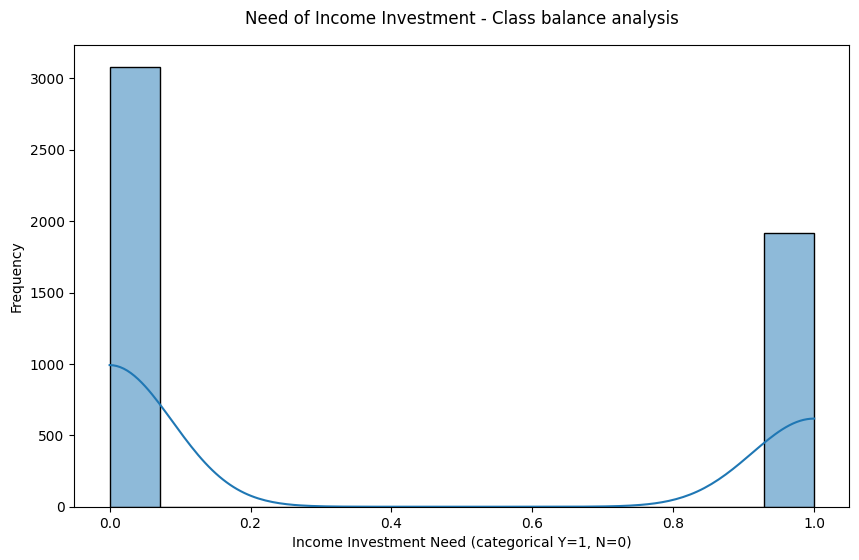

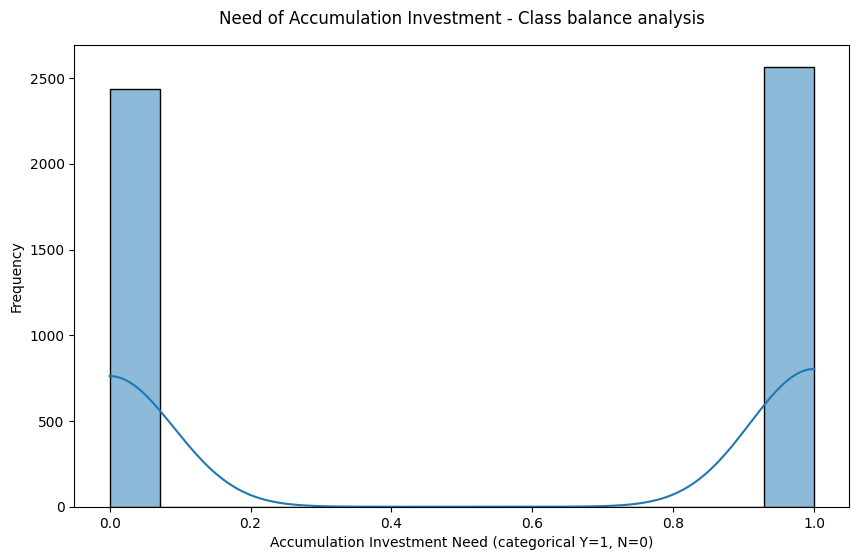

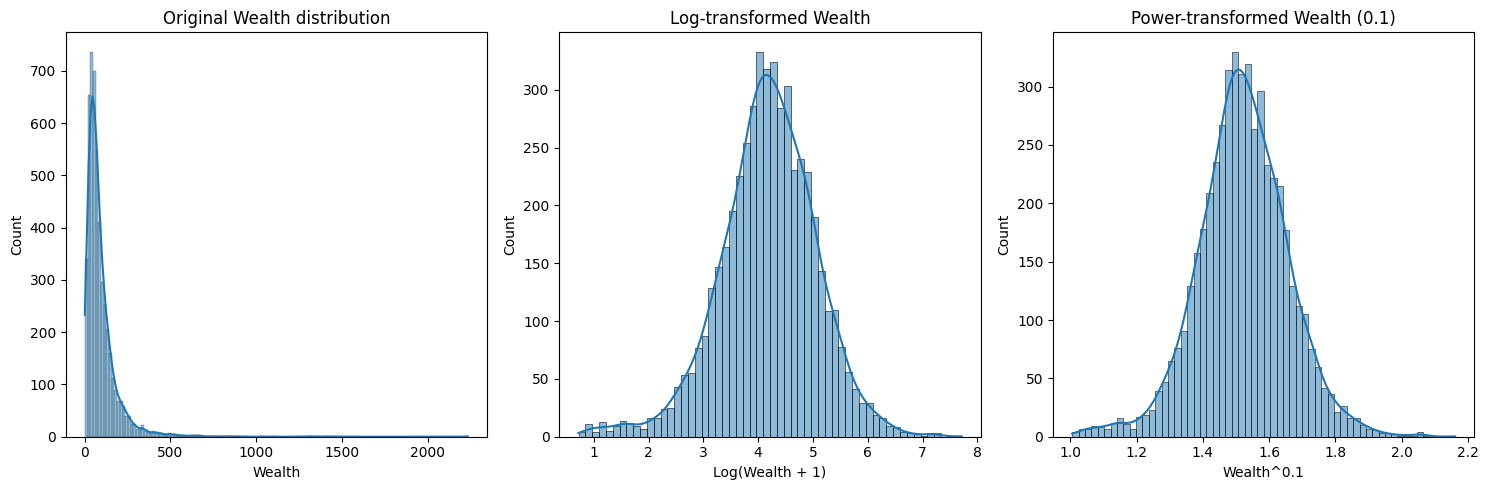

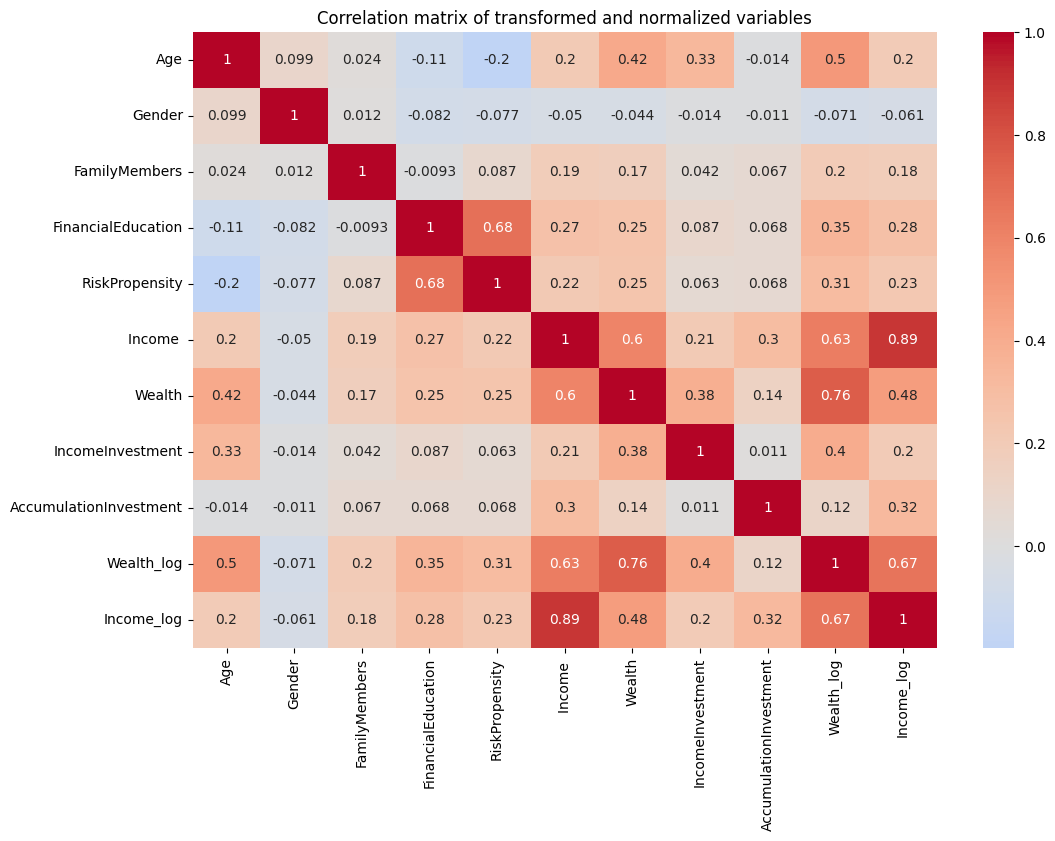

<Figure size 1500x1500 with 0 Axes>

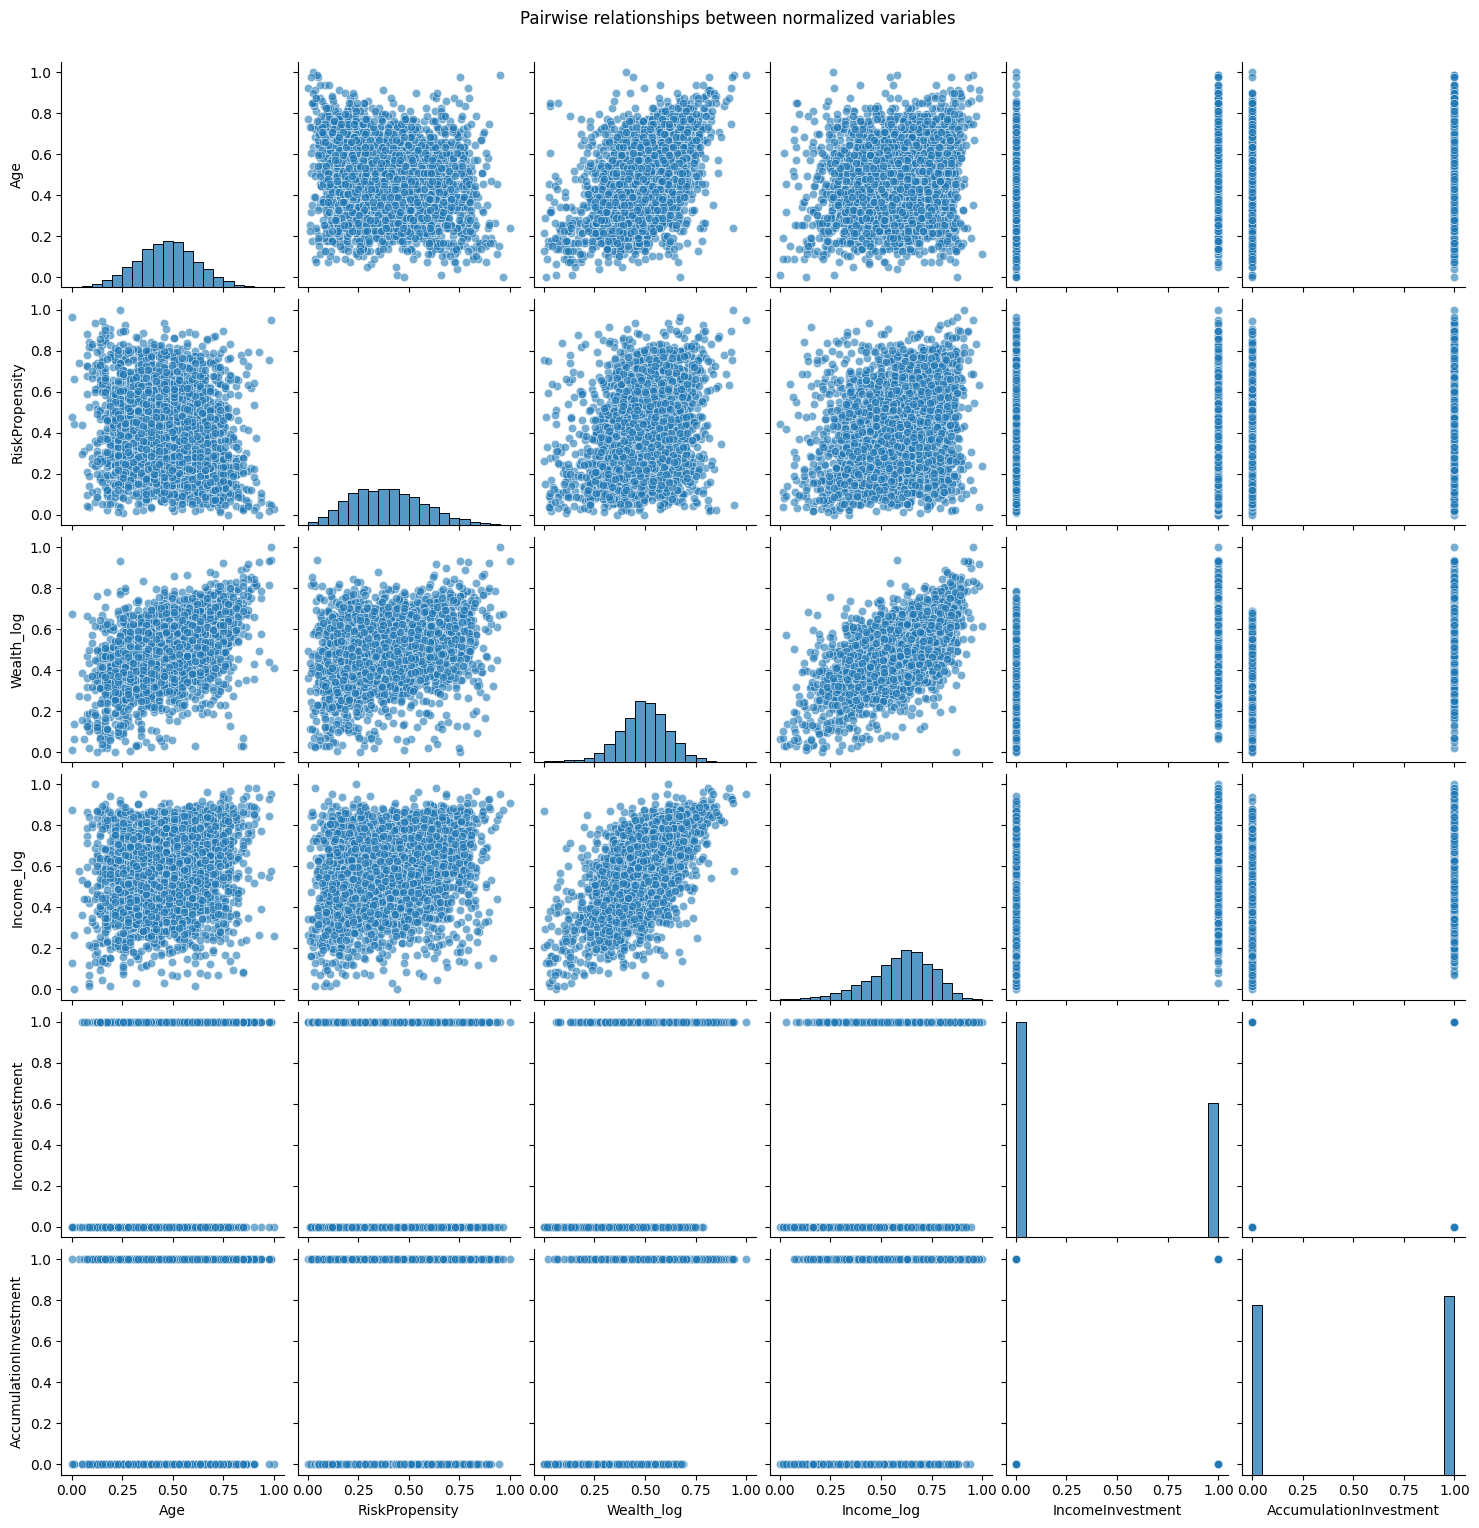

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Create df with all transformations and normalizations
transformed_df = needs_df.copy()

# Create a function for histogram plotting
def plot_histogram(data, title, xlabel, ylabel="Frequency"):
    plt.figure(figsize=(10, 6))
    sns.histplot(data, kde=True)
    plt.title(title, pad=15)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


# Plot class balance histograms
plot_histogram(needs_df.IncomeInvestment,
              'Need of Income Investment - Class balance analysis',
              'Income Investment Need (categorical Y=1, N=0)')

plot_histogram(needs_df.AccumulationInvestment,
              'Need of Accumulation Investment - Class balance analysis',
              'Accumulation Investment Need (categorical Y=1, N=0)')

# Wealth transformation analysis
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Original distribution
sns.histplot(needs_df.Wealth, kde=True, ax=ax1)
ax1.set_title('Original Wealth distribution')
ax1.set_xlabel('Wealth')

# Log transformation
sns.histplot(np.log1p(needs_df.Wealth), kde=True, ax=ax2)
ax2.set_title('Log-transformed Wealth')
ax2.set_xlabel('Log(Wealth + 1)')

# Power transformation
sns.histplot(np.power(needs_df.Wealth, 0.1), kde=True, ax=ax3)
ax3.set_title('Power-transformed Wealth (0.1)')
ax3.set_xlabel('Wealth^0.1')

plt.tight_layout()
plt.show()

# Apply log transformations
transformed_df['Wealth_log'] = np.log1p(transformed_df['Wealth'])
transformed_df['Income_log'] = np.log1p(transformed_df['Income '])

# Apply MinMaxScaler to numerical variables
scaler = MinMaxScaler()
vars_to_normalize = ['Age', 'RiskPropensity', 'Wealth_log', 'Income_log']
transformed_df[vars_to_normalize] = scaler.fit_transform(transformed_df[vars_to_normalize])

# Get all numeric columns including transformed ones (and not transformed, for comparison)
numeric_cols = transformed_df.select_dtypes(include=['float64', 'int64']).columns

# Create correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(transformed_df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm',
            center=0)
plt.title('Correlation matrix of transformed and normalized variables')
plt.show()

# Create enhanced pairplot
vars_to_plot = vars_to_normalize + ['IncomeInvestment', 'AccumulationInvestment']
plt.figure(figsize=(15, 15))
sns.pairplot(transformed_df[vars_to_plot],
             diag_kind='hist',
             plot_kws={'alpha': 0.6},
             diag_kws={'bins': 20})
plt.suptitle('Pairwise relationships between normalized variables', y=1.02)
plt.show()

## Train and evaluate baseline classifiers
Prepare features, run cross-validated SVM/Naive Bayes training, and report metrics with ROC curves.


Target Variable: Income Investment

SVM - Base Features
+---+-----------+--------------------+----------------------+----------+
|   |  Metric   |      CV Mean       |        CV Std        | Test Set |
+---+-----------+--------------------+----------------------+----------+
| 0 | Accuracy  | 0.7827500000000001 | 0.017237314175938222 |  0.764   |
| 1 | Precision | 0.8322028075117138 | 0.020560096163658306 |  0.827   |
| 2 |  Recall   | 0.5423729535245151 | 0.03960037201648322  |  0.487   |
| 3 |    F1     | 0.6562269465287243 | 0.034108044499821084 |  0.613   |
| 4 |    AUC    |         -          |          -           |   0.74   |
+---+-----------+--------------------+----------------------+----------+

SVM - Engineered Features
+---+-----------+--------------------+---------------------+----------+
|   |  Metric   |      CV Mean       |       CV Std        | Test Set |
+---+-----------+--------------------+---------------------+----------+
| 0 | Accuracy  |      0.78825       | 0.01

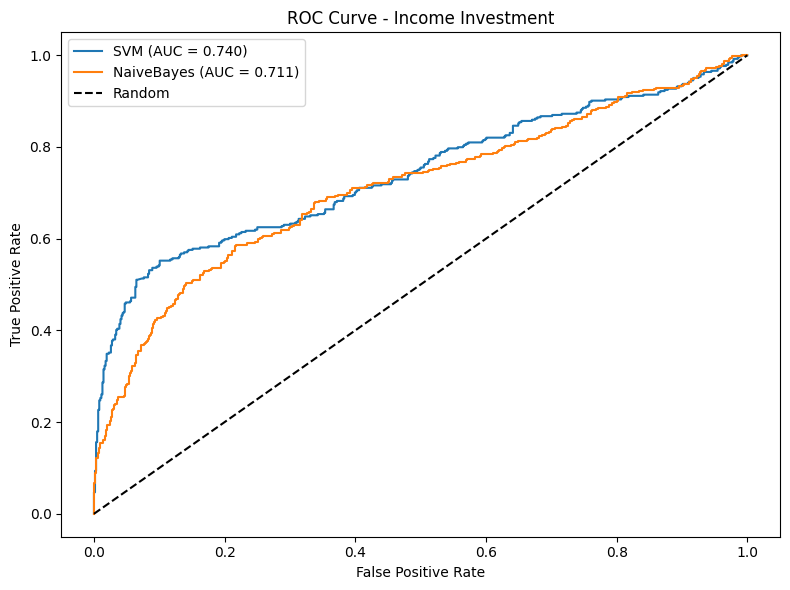


Target Variable: Accumulation Investment

SVM - Base Features
+---+-----------+--------------------+----------------------+----------+
|   |  Metric   |      CV Mean       |        CV Std        | Test Set |
+---+-----------+--------------------+----------------------+----------+
| 0 | Accuracy  | 0.7542500000000001 | 0.01974208702239962  |  0.747   |
| 1 | Precision | 0.7871454585849318 | 0.02133642354252533  |  0.764   |
| 2 |  Recall   | 0.7145759895555159 | 0.02238566238689773  |  0.733   |
| 3 |    F1     | 0.7490094503945837 | 0.020281871352548584 |  0.748   |
| 4 |    AUC    |         -          |          -           |   0.8    |
+---+-----------+--------------------+----------------------+----------+

SVM - Engineered Features
+---+-----------+--------------------+----------------------+----------+
|   |  Metric   |      CV Mean       |        CV Std        | Test Set |
+---+-----------+--------------------+----------------------+----------+
| 0 | Accuracy  |      0.76525    

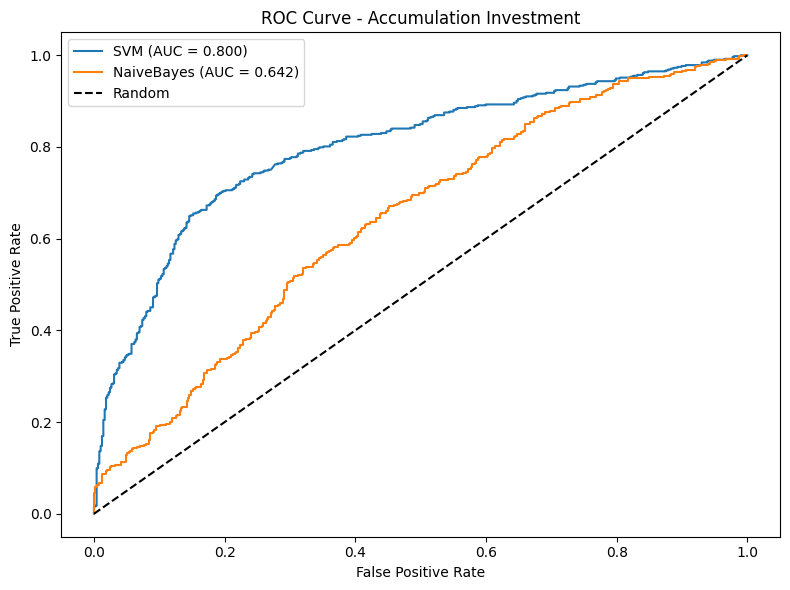

In [58]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tabulate import tabulate
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.preprocessing import PowerTransformer, StandardScaler

def prepare_features(df):
    X = df.copy()

    # Normalize column name
    if 'Income ' in X.columns:
        X = X.rename(columns={'Income ': 'Income'})

    # 1. Log transformations (Keep these as they help the scaler)
    X['Wealth_log'] = np.log1p(X['Wealth'])
    X['Income_log'] = np.log1p(X['Income'])

    # 2. Ratio features
    X['Income_Wealth_Ratio'] = X['Income'] / X['Wealth'].replace(0, np.nan)
    X['Income_Wealth_Ratio'] = X['Income_Wealth_Ratio'].fillna(X['Income'].max())
    X['Income_Wealth_Ratio_log'] = np.log1p(X['Income_Wealth_Ratio'])

    # 3. Risk interaction features
    X['Income_Risk']  = X['Income_log'] * X['RiskPropensity']
    X['Wealth_Risk']  = X['Wealth_log'] * X['RiskPropensity']
    X['FinEdu_Risk']  = X['FinancialEducation'] * X['RiskPropensity']

    # 4. Lifecycle features
    X['years_to_retire'] = (65 - X['Age']).clip(lower=0)
    X['wealth_per_year'] = X['Wealth_log'] / (X['years_to_retire'] + 1)

    X['Income_per_Family'] = X['Income_log'] / X['FamilyMembers'].replace(0, np.nan)
    X['Income_per_Family'] = X['Income_per_Family'].fillna(X['Income_log'].max())
    X['Wealth_Income_Ratio'] = X['Wealth_log'] / (X['Income'] + 1)

    features_base = [
        'Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
        'RiskPropensity', 'Wealth_log', 'Income_log'
    ]
    features_engineered = [
        'Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
        'RiskPropensity', 'Wealth_log', 'Income_log',
        'Income_Wealth_Ratio_log',
        'Income_Risk', 'Wealth_Risk', 'FinEdu_Risk', 'Wealth_Income_Ratio'
    ]

    # --- THE FIX: Use PowerTransformer instead of MinMaxScaler ---
    # method='yeo-johnson' works with both positive and negative numbers.
    scaler = PowerTransformer(method='yeo-johnson')

    X_base       = pd.DataFrame(scaler.fit_transform(X[features_base]),       columns=features_base,       index=X.index)
    X_engineered = pd.DataFrame(scaler.fit_transform(X[features_engineered]), columns=features_engineered, index=X.index)

    return X_base, X_engineered
def split_data(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test

# Step 3: Model training and evaluation function
def train_evaluate_model(X_train, y_train, X_test, y_test, model, k_folds=5):
    kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    cv_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train,y_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict(X_val_fold)
        cv_metrics['accuracy'].append(accuracy_score(y_val_fold, y_val_pred))
        cv_metrics['precision'].append(precision_score(y_val_fold, y_val_pred))
        cv_metrics['recall'].append(recall_score(y_val_fold, y_val_pred))
        cv_metrics['f1'].append(f1_score(y_val_fold, y_val_pred))

    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    return {
        'model': model,
        'cv_metrics': {
            metric: {'mean': np.mean(scores), 'std': np.std(scores)}
            for metric, scores in cv_metrics.items()
        },
        'test_metrics': {
            'accuracy':  accuracy_score(y_test, y_test_pred),
            'precision': precision_score(y_test, y_test_pred),
            'recall':    recall_score(y_test, y_test_pred),
            'f1':        f1_score(y_test, y_test_pred),
            'auc':       roc_auc_score(y_test, y_test_proba)
        },
        'y_test_proba': y_test_proba
    }


# Step 4: Display results function
def display_results_table(results_dict, model_name, feature_type):
    cv_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
        'CV Mean': [
            results_dict['cv_metrics']['accuracy']['mean'],
            results_dict['cv_metrics']['precision']['mean'],
            results_dict['cv_metrics']['recall']['mean'],
            results_dict['cv_metrics']['f1']['mean'],
            '-'
        ],
        'CV Std': [
            results_dict['cv_metrics']['accuracy']['std'],
            results_dict['cv_metrics']['precision']['std'],
            results_dict['cv_metrics']['recall']['std'],
            results_dict['cv_metrics']['f1']['std'],
            '-'
        ],
        'Test Set': [
            results_dict['test_metrics']['accuracy'],
            results_dict['test_metrics']['precision'],
            results_dict['test_metrics']['recall'],
            results_dict['test_metrics']['f1'],
            results_dict['test_metrics']['auc']
        ]
    }
    df = pd.DataFrame(cv_data)
    df = df.round(3)
    print(f"\n{model_name} - {feature_type}")
    print("=" * 60)
    print(tabulate(df, headers='keys', tablefmt='pretty'))


# Step 5: Run full analysis
X_base, X_engineered = prepare_features(needs_df)
y_income = needs_df['IncomeInvestment']
y_accum  = needs_df['AccumulationInvestment']

models = {
    'SVM':        SVC(probability=True),
    'NaiveBayes': GaussianNB()
}

for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nTarget Variable: {target_name}")
    print("=" * 80)

    X_base_train, X_base_test, y_train, y_test = split_data(X_base, y)
    X_eng_train,  X_eng_test,  _,       _      = split_data(X_engineered, y)

    all_results = {}
    for model_name, model in models.items():
        results_base = train_evaluate_model(X_base_train, y_train, X_base_test, y_test, model)
        display_results_table(results_base, model_name, "Base Features")

        results_eng = train_evaluate_model(X_eng_train, y_train, X_eng_test, y_test, model)
        display_results_table(results_eng, model_name, "Engineered Features")

        all_results[model_name] = results_base

    plt.figure(figsize=(8, 6))
    for model_name, results in all_results.items():
        fpr, tpr, _ = roc_curve(y_test, results['y_test_proba'])
        auc = results['test_metrics']['auc']
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {target_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

## XGBoost benchmark
Train and evaluate an XGBoost classifier on base and engineered features.

In [59]:
import xgboost as xgb

# Updated XGBoost configuration
models = {
    'XGBoost': xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

# Run the analysis
for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nTarget Variable: {target_name}")
    print("=" * 80)

    X_base_train, X_base_test, y_train, y_test = split_data(X_base, y)
    X_eng_train, X_eng_test, _, _ = split_data(X_engineered, y)

    model = models['XGBoost']

    results_base = train_evaluate_model(X_base_train, y_train, X_base_test, y_test, model)
    display_results_table(results_base, 'XGBoost', "Base Features")

    results_eng = train_evaluate_model(X_eng_train, y_train, X_eng_test, y_test, model)
    display_results_table(results_eng, 'XGBoost', "Engineered Features")



Target Variable: Income Investment

XGBoost - Base Features
+---+-----------+--------------------+----------------------+----------+
|   |  Metric   |      CV Mean       |        CV Std        | Test Set |
+---+-----------+--------------------+----------------------+----------+
| 0 | Accuracy  |      0.78975       | 0.012283118496538244 |  0.763   |
| 1 | Precision | 0.7869796327642041 | 0.027264268034811173 |  0.765   |
| 2 |  Recall   | 0.6205978156735006 | 0.02179130105811132  |  0.552   |
| 3 |    F1     | 0.6935799528437123 | 0.017663135957515907 |  0.641   |
| 4 |    AUC    |         -          |          -           |  0.752   |
+---+-----------+--------------------+----------------------+----------+

XGBoost - Engineered Features
+---+-----------+--------------------+----------------------+----------+
|   |  Metric   |      CV Mean       |        CV Std        | Test Set |
+---+-----------+--------------------+----------------------+----------+
| 0 | Accuracy  |       0.8055  

## Random Forest benchmark
Train and evaluate a Random Forest model for both target variables.

In [60]:
from sklearn.ensemble import RandomForestClassifier

# Updated Rf configuration
models = {
    'RandomForest': RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        criterion='gini',
        class_weight={0: 1.0, 1: 1.6}
    )
}

# Run the analysis
for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nTarget Variable: {target_name}")
    print("=" * 80)

    X_base_train, X_base_test, y_train, y_test = split_data(X_base, y)
    X_eng_train, X_eng_test, _, _ = split_data(X_engineered, y)

    model = models['RandomForest']

    results_base = train_evaluate_model(X_base_train, y_train, X_base_test, y_test, model)
    display_results_table(results_base, 'RandomForest', "Base Features")

    results_eng = train_evaluate_model(X_eng_train, y_train, X_eng_test, y_test, model)
    display_results_table(results_eng, 'RandomForest', "Engineered Features")



Target Variable: Income Investment

RandomForest - Base Features
+---+-----------+--------------------+----------------------+----------+
|   |  Metric   |      CV Mean       |        CV Std        | Test Set |
+---+-----------+--------------------+----------------------+----------+
| 0 | Accuracy  |       0.8115       | 0.00985520167221349  |  0.775   |
| 1 | Precision | 0.8480673700872812 | 0.018791162021556396 |  0.822   |
| 2 |  Recall   | 0.6199527367950437 | 0.025204814315460847 |  0.529   |
| 3 |    F1     | 0.7158957149956999 | 0.01777861097366781  |  0.643   |
| 4 |    AUC    |         -          |          -           |  0.768   |
+---+-----------+--------------------+----------------------+----------+

RandomForest - Engineered Features
+---+-----------+--------------------+----------------------+----------+
|   |  Metric   |      CV Mean       |        CV Std        | Test Set |
+---+-----------+--------------------+----------------------+----------+
| 0 | Accuracy  | 0.82

## Interpretability helper functions
Define reusable training output and feature-importance plotting utilities.

In [61]:
# Rewrite the function, returning the trained model, too
def train_evaluate_model(X_train, y_train, X_test, y_test, model, k_folds=5):
    kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    cv_metrics = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': []
    }

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict(X_val_fold)

        cv_metrics['accuracy'].append(accuracy_score(y_val_fold, y_val_pred))
        cv_metrics['precision'].append(precision_score(y_val_fold, y_val_pred))
        cv_metrics['recall'].append(recall_score(y_val_fold, y_val_pred))
        cv_metrics['f1'].append(f1_score(y_val_fold, y_val_pred))

    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)

    return {
        'cv_metrics': {
            metric: {
                'mean': np.mean(scores),
                'std': np.std(scores)
            } for metric, scores in cv_metrics.items()
        },
        'test_metrics': {
            'accuracy': accuracy_score(y_test, y_test_pred),
            'precision': precision_score(y_test, y_test_pred),
            'recall': recall_score(y_test, y_test_pred),
            'f1': f1_score(y_test, y_test_pred)
        },
        'model': model
    }


# Feature importance function: capture the trained models during our initial
# training phase and then use them for feature importance analysis
def plot_feature_importance(model, feature_names, title):
    importances = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    })
    importances = importances.sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importances, x='importance', y='feature')
    plt.title(title)
    plt.xlabel('Feature Importance')
    plt.tight_layout()
    plt.show()


## Global SHAP summaries
SHAP summary plots to explain global feature impact for tree-based models.

In [62]:
import shap

def plot_shap_values(model, X, title):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X, plot_type="bar", show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X, show=False)
    plt.title(f"{title} - Feature Impacts")
    plt.tight_layout()
    plt.show()

## Local SHAP explanations
Waterfall-style SHAP explanation for one selected test instance.

In [63]:
def plot_loc_shap_values(model, X, title, instance_idx):
    explainer = shap.TreeExplainer(results['model'])
    shap_explanation = explainer(X_eng_test) 

# For binary classification, take positive class
    if len(shap_explanation.shape) == 3:
     shap_explanation = shap_explanation[:, :, 1]

    shap.plots.waterfall(shap_explanation[instance_idx], show=False)
    plt.title(f"{title} - SHAP Waterfall for {instance_idx}th Test Instance")
    plt.tight_layout()
    plt.show()


## Local LIME explanations
LIME-based local interpretability for an individual prediction.

In [64]:
#LIME for local interpretability
from lime.lime_tabular import LimeTabularExplainer


def plot_loc_lime_values(model, X, title, instance_idx):
    explainer_lime = LimeTabularExplainer(
    training_data=X_eng_train.values,
    feature_names=X_engineered.columns.tolist(),
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

    explanation = explainer_lime.explain_instance(
    data_row=X_eng_test.iloc[instance_idx].values,
    predict_fn=results['model'].predict_proba,
    num_features=len(X_engineered.columns)
)

    explanation.as_pyplot_figure()
    plt.title(f"{title} for {instance_idx}th Test Instance")
    plt.tight_layout()
    plt.show()

## Basic MLP implementation
The next cell defines a PyTorch MLP, dataset wrappers, and training loop for both targets.

In [65]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Detect device — MPS for Apple Silicon, else CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

class InvestmentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values.copy())
        self.y = torch.FloatTensor(y.values.copy())
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.layers(x)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # move to device
            optimizer.zero_grad()
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        model.eval()
        val_loss = 0
        val_preds = []
        val_true = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # move to device
                y_pred = model(X_batch).squeeze()
                val_loss += criterion(y_pred, y_batch).item()
                val_preds.extend((y_pred > 0.5).float().cpu().numpy())  # .cpu() before numpy
                val_true.extend(y_batch.cpu().numpy())                   # .cpu() before numpy
        if (epoch + 1) % 1 == 0:
            print(f'Epoch {epoch+1}, Train Loss: {train_loss/len(train_loader):.4f}, '
                  f'Val Loss: {val_loss/len(val_loader):.4f}, '
                  f'Val Accuracy: {accuracy_score(val_true, val_preds):.4f}')

for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nTraining Neural Network for {target_name}")
    print("=" * 50)
    X_train, X_test, y_train, y_test = split_data(X_engineered, y)
    train_dataset = InvestmentDataset(X_train, y_train)
    test_dataset = InvestmentDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=128)
    model = MLP(input_size=X_train.shape[1]).to(device)  # move model to device
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_model(model, train_loader, test_loader, criterion, optimizer)

Using device: cpu

Training Neural Network for Income Investment
Epoch 1, Train Loss: 0.6547, Val Loss: 0.6173, Val Accuracy: 0.7320
Epoch 2, Train Loss: 0.5857, Val Loss: 0.5735, Val Accuracy: 0.7430
Epoch 3, Train Loss: 0.5488, Val Loss: 0.5558, Val Accuracy: 0.7470
Epoch 4, Train Loss: 0.5324, Val Loss: 0.5411, Val Accuracy: 0.7560
Epoch 5, Train Loss: 0.5249, Val Loss: 0.5414, Val Accuracy: 0.7530
Epoch 6, Train Loss: 0.5147, Val Loss: 0.5384, Val Accuracy: 0.7540
Epoch 7, Train Loss: 0.5194, Val Loss: 0.5364, Val Accuracy: 0.7650
Epoch 8, Train Loss: 0.5114, Val Loss: 0.5338, Val Accuracy: 0.7610
Epoch 9, Train Loss: 0.5105, Val Loss: 0.5330, Val Accuracy: 0.7580
Epoch 10, Train Loss: 0.5047, Val Loss: 0.5326, Val Accuracy: 0.7600

Training Neural Network for Accumulation Investment
Epoch 1, Train Loss: 0.6806, Val Loss: 0.6508, Val Accuracy: 0.6470
Epoch 2, Train Loss: 0.6377, Val Loss: 0.6274, Val Accuracy: 0.6870
Epoch 3, Train Loss: 0.6137, Val Loss: 0.6082, Val Accuracy: 0.70

## Evaluate neural network performance
The next cell computes confusion matrices and training/test metrics for the trained MLP.


Results for Income Investment


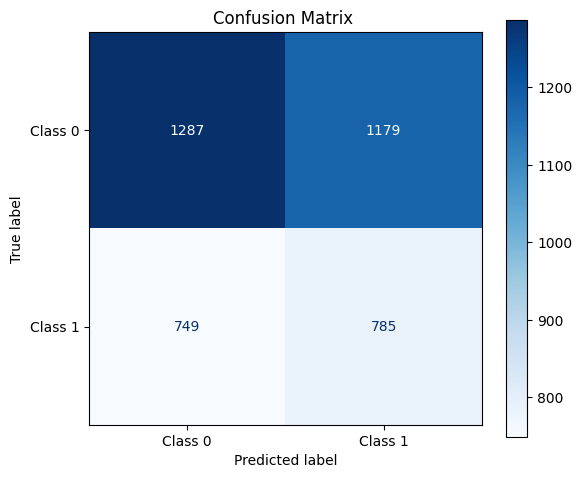

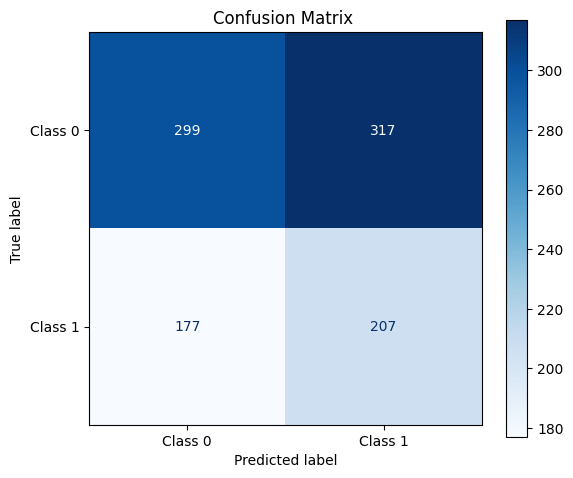


Neural Network Metrics:
           Training   Test
accuracy      0.518  0.506
precision     0.400  0.395
recall        0.512  0.539
f1            0.449  0.456

Results for Accumulation Investment


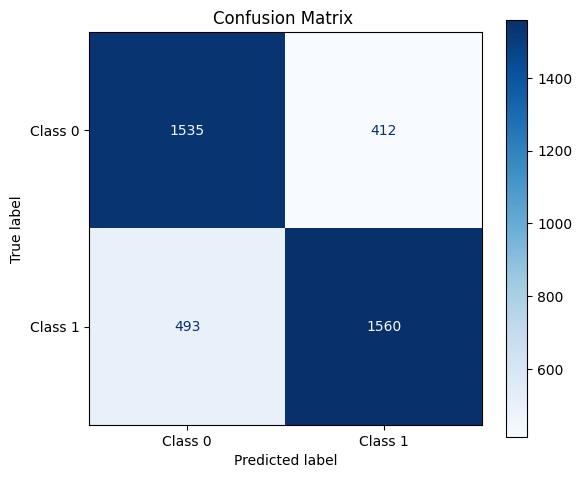

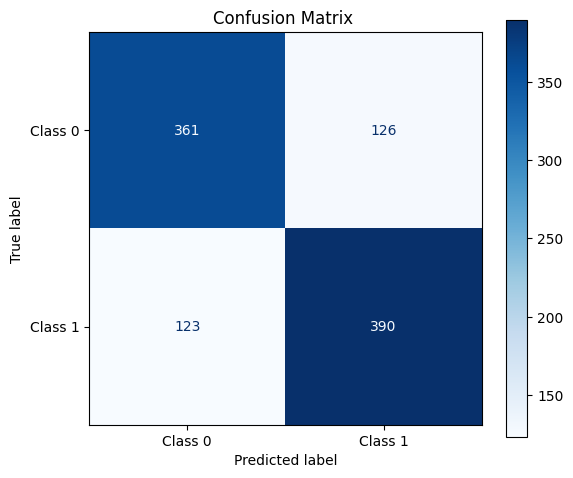


Neural Network Metrics:
           Training   Test
accuracy      0.774  0.751
precision     0.791  0.756
recall        0.760  0.760
f1            0.775  0.758


In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluate_nn_metrics(model, data_loader, title=""):
    model.eval()
    all_preds = []
    all_true = []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch).squeeze()
            all_preds.extend((y_pred > 0.5).float().cpu().numpy())
            all_true.extend(y_batch.cpu().numpy())

    # Confusion matrix
    cm = confusion_matrix(all_true, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
    plt.figure(figsize=(6, 5))
    disp.plot(cmap='Blues', ax=plt.gca())
    plt.title(f"Confusion Matrix {title}")
    plt.tight_layout()
    plt.show()

    return {
        'accuracy':  accuracy_score(all_true, all_preds),
        'precision': precision_score(all_true, all_preds),
        'recall':    recall_score(all_true, all_preds),
        'f1':        f1_score(all_true, all_preds)
    }

for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nResults for {target_name}")
    print("=" * 50)
    X_train, X_test, y_train, y_test = split_data(X_engineered, y)
    train_dataset = InvestmentDataset(X_train, y_train)
    test_dataset = InvestmentDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)  # also bumped to 128
    test_loader = DataLoader(test_dataset, batch_size=128)
    train_metrics = evaluate_nn_metrics(model, train_loader)
    test_metrics = evaluate_nn_metrics(model, test_loader)
    metrics_df = pd.DataFrame({
        'Training': train_metrics,
        'Test': test_metrics
    }).round(3)
    print("\nNeural Network Metrics:")
    print(metrics_df)

## Define Optuna search components
Tunable MLP architecture and Optuna objective/training utilities.

In [67]:
import optuna
from sklearn.metrics import fbeta_score
from optuna.trial import TrialState
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

class MLP(nn.Module):
    def __init__(self, input_size, layer_sizes, dropouts, use_batchnorm):
        super(MLP, self).__init__()
        layers = []
        in_features = input_size

        for i, (out_features, dropout) in enumerate(zip(layer_sizes, dropouts)):
            layers.append(nn.Linear(in_features, out_features))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(out_features))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_features = out_features

        layers.append(nn.Linear(in_features, 1))
        layers.append(nn.Sigmoid())
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)


def train_model_with_curves(model, train_loader, val_loader, criterion, optimizer, epochs=100):
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    train_losses = []
    val_losses = []
    val_accuracies = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # move to device
            optimizer.zero_grad()
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        model.eval()
        val_loss = 0
        val_preds = []
        val_true = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # move to device
                y_pred = model(X_batch).squeeze()
                val_loss += criterion(y_pred, y_batch).item()
                val_preds.extend((y_pred > 0.5).float().cpu().numpy())  # .cpu() before numpy
                val_true.extend(y_batch.cpu().numpy())                   # .cpu() before numpy
        train_losses.append(train_loss/len(train_loader))
        val_losses.append(val_loss/len(val_loader))
        val_accuracies.append(accuracy_score(val_true, val_preds))
        scheduler.step(val_loss)
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, '
                  f'Val Loss: {val_losses[-1]:.4f}, '
                  f'Val Accuracy: {val_accuracies[-1]:.4f}')
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.title('Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return model

def train_and_evaluate(model, train_loader, val_loader, optimizer, epochs=50):
    criterion = nn.BCELoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )
    best_val_acc = 0.0

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch).squeeze(), y_batch)
            loss.backward()
            optimizer.step()

        # --- Validate ---
        model.eval()
        val_loss, val_preds, val_true = 0.0, [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch).squeeze()
                val_loss += criterion(y_pred, y_batch).item()
                val_preds.extend((y_pred > 0.5).float().cpu().numpy())
                val_true.extend(y_batch.cpu().numpy())

        scheduler.step(val_loss)
        val_acc = fbeta_score(val_true, val_preds, beta=1)
        best_val_acc = max(best_val_acc, val_acc)

    return best_val_acc


# ── 3. Optuna objective ────────────────────────────────────────────────────────

def make_objective(X_train, y_train, X_val, y_val, input_size):

    def objective(trial):
        # --- Architecture ---
        n_layers = trial.suggest_int("n_layers", 1, 4)
        layer_sizes = [
            trial.suggest_int(f"units_l{i}", 16, 256, step=16)
            for i in range(n_layers)
        ]
        dropouts = [
            trial.suggest_float(f"dropout_l{i}", 0.1, 0.5)
            for i in range(n_layers)
        ]
        use_batchnorm = trial.suggest_categorical("use_batchnorm", [True, False])

        # --- Optimizer ---
        optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "RMSprop", "SGD"])
        lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

        # --- DataLoader ---
        batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])

        train_loader = DataLoader(
            InvestmentDataset(X_train, y_train), batch_size=batch_size, shuffle=True
        )
        val_loader = DataLoader(
            InvestmentDataset(X_val, y_val), batch_size=batch_size
        )

        # --- Build model & optimizer ---
        model = MLP(input_size, layer_sizes, dropouts, use_batchnorm).to(device)
        optimizer = getattr(optim, optimizer_name)(
            model.parameters(), lr=lr, weight_decay=weight_decay
        )

        val_acc = train_and_evaluate(model, train_loader, val_loader, optimizer, epochs=50)

        return val_acc

    return objective

## Run Optuna tuning for MLP
The next cell executes hyperparameter search, retrains the best model, and reports final metrics.

[I 2026-04-16 16:08:43,132] A new study created in memory with name: Income Investment



Optuna Search for: Income Investment


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-16 16:08:46,156] Trial 0 finished with value: 0.6411483253588517 and parameters: {'n_layers': 2, 'units_l0': 96, 'units_l1': 80, 'dropout_l0': 0.2425013110666149, 'dropout_l1': 0.4989474975976088, 'use_batchnorm': False, 'optimizer': 'Adam', 'lr': 0.050914342510105744, 'weight_decay': 9.701072677147711e-05, 'batch_size': 256}. Best is trial 0 with value: 0.6411483253588517.
[I 2026-04-16 16:08:48,704] Trial 1 finished with value: 0.6292834890965732 and parameters: {'n_layers': 1, 'units_l0': 64, 'dropout_l0': 0.22176432043594568, 'use_batchnorm': False, 'optimizer': 'RMSprop', 'lr': 0.03517130014418644, 'weight_decay': 0.0013340500996899315, 'batch_size': 256}. Best is trial 0 with value: 0.6411483253588517.
[I 2026-04-16 16:08:55,027] Trial 2 finished with value: 0.6438569206842923 and parameters: {'n_layers': 3, 'units_l0': 208, 'units_l1': 96, 'units_l2': 112, 'dropout_l0': 0.32134245413322715, 'dropout_l1': 0.16076279279805453, 'dropout_l2': 0.3778102195412678, 'use_batc

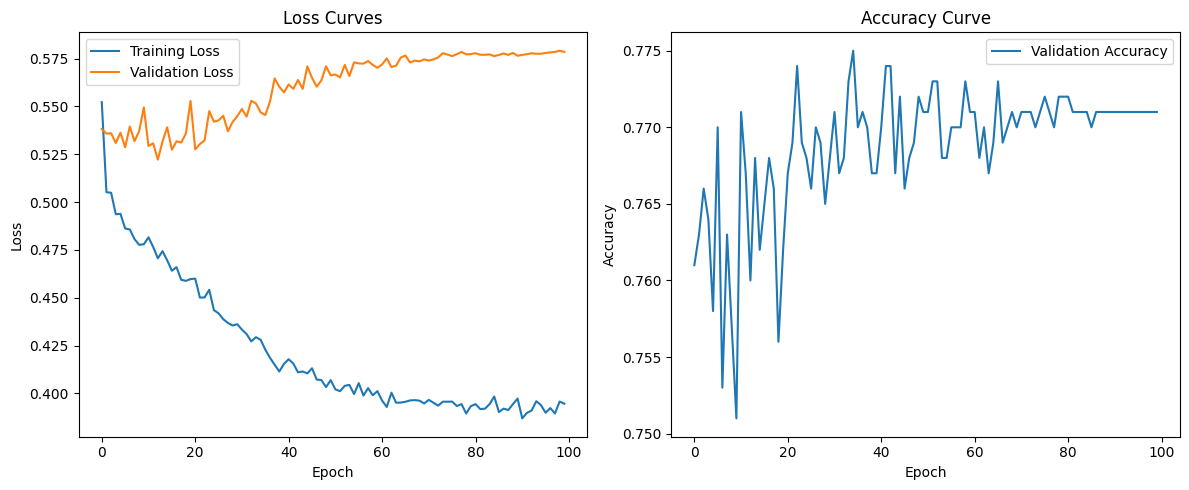

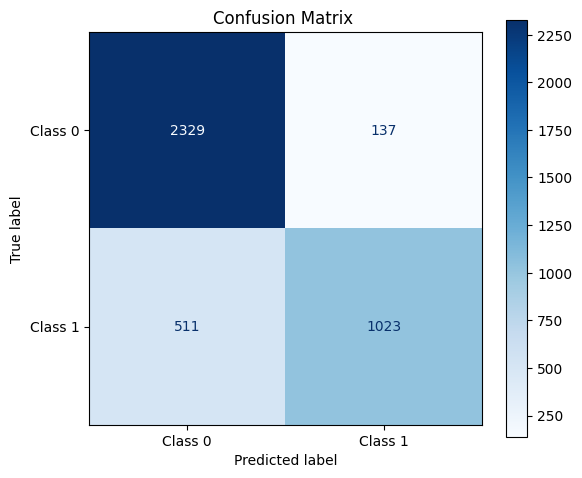

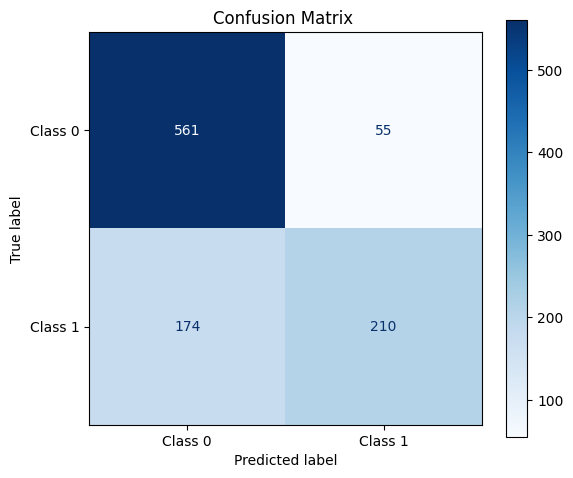

[I 2026-04-16 16:13:48,371] A new study created in memory with name: Accumulation Investment



Final Metrics — Income Investment:
           Training   Test
accuracy      0.838  0.771
precision     0.882  0.792
recall        0.667  0.547
f1            0.759  0.647

Confusion Matrix:

Optuna Search for: Accumulation Investment


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-16 16:13:53,738] Trial 0 finished with value: 0.8 and parameters: {'n_layers': 3, 'units_l0': 16, 'units_l1': 64, 'units_l2': 128, 'dropout_l0': 0.15255617999929494, 'dropout_l1': 0.20006595683539224, 'dropout_l2': 0.20058301904520712, 'use_batchnorm': False, 'optimizer': 'RMSprop', 'lr': 0.0021306579132564837, 'weight_decay': 0.00024929215465481177, 'batch_size': 64}. Best is trial 0 with value: 0.8.
[I 2026-04-16 16:13:58,101] Trial 1 finished with value: 0.7537688442211056 and parameters: {'n_layers': 1, 'units_l0': 48, 'dropout_l0': 0.3878469275343327, 'use_batchnorm': True, 'optimizer': 'Adam', 'lr': 0.08977396215978024, 'weight_decay': 2.327847400954573e-06, 'batch_size': 64}. Best is trial 0 with value: 0.8.
[I 2026-04-16 16:14:01,255] Trial 2 finished with value: 0.7553816046966731 and parameters: {'n_layers': 1, 'units_l0': 80, 'dropout_l0': 0.2579891810127396, 'use_batchnorm': False, 'optimizer': 'SGD', 'lr': 0.04974591181713232, 'weight_decay': 6.085681193305881e-

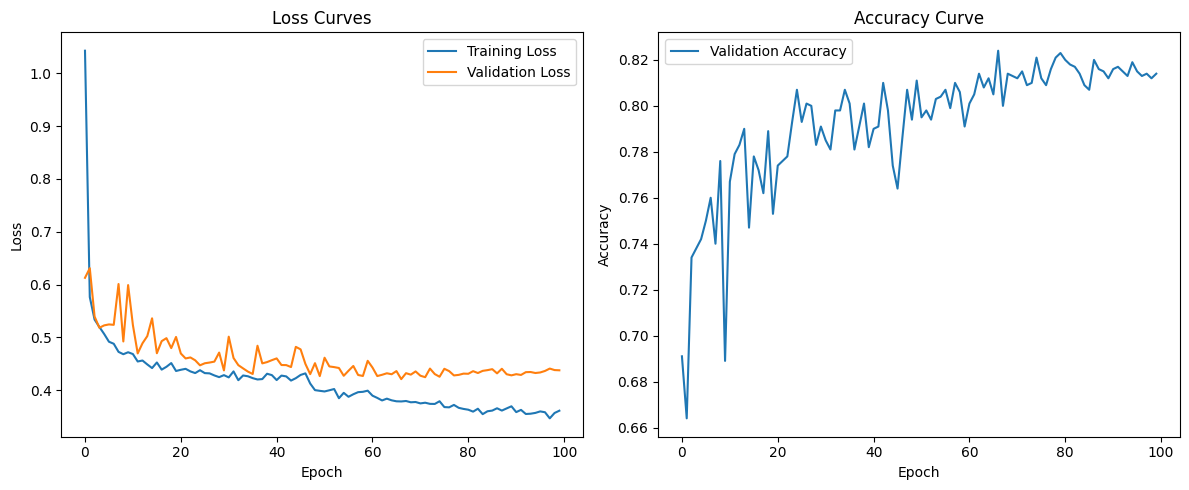

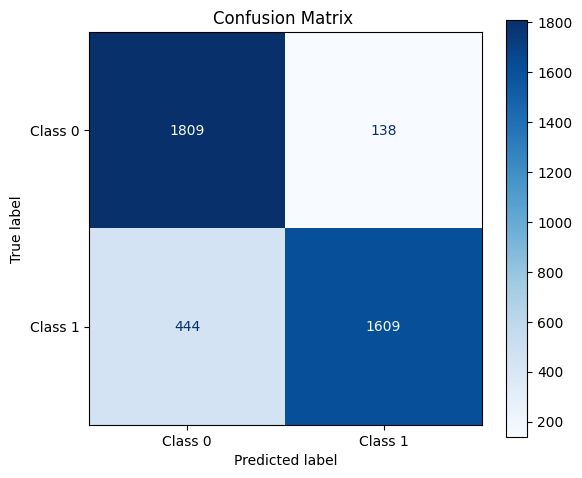

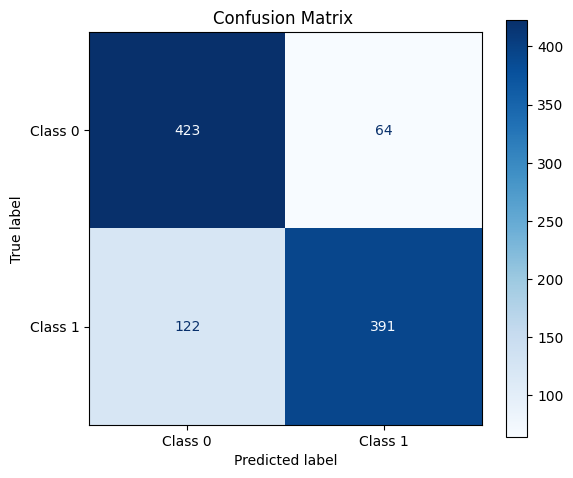


Final Metrics — Accumulation Investment:
           Training   Test
accuracy      0.854  0.814
precision     0.921  0.859
recall        0.784  0.762
f1            0.847  0.808

Confusion Matrix:


In [68]:
best_mlp_params = {}
best_mlp_models = {}
for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nOptuna Search for: {target_name}")
    print("=" * 50)

    X_train, X_test, y_train, y_test = split_data(X_engineered, y)
    input_size = X_train.shape[1]

    study = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
        study_name=target_name
    )
    study.optimize(
        make_objective(X_train, y_train, X_test, y_test, input_size),
        n_trials=30,
        timeout=600,          
        show_progress_bar=True
    )

    # --- Results ---
    pruned  = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
    complete = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

    print(f"\n  Finished trials FOR ENGINEERED FEATURES : {len(study.trials)}")
    print(f"  Pruned          : {len(pruned)}")
    print(f"  Completed       : {len(complete)}")
    print(f"\n  Best val accuracy : {study.best_trial.value:.4f}")
    print("  Best params:")
    for k, v in study.best_trial.params.items():
        print(f"    {k}: {v}")

    # --- Retrain best model with full curves ---
    p = study.best_trial.params
    n = p["n_layers"]
    best_layer_sizes = [p[f"units_l{i}"] for i in range(n)]
    best_dropouts    = [p[f"dropout_l{i}"] for i in range(n)]
    
    

    best_model = MLP(input_size, best_layer_sizes, best_dropouts, p["use_batchnorm"]).to(device)
    best_optimizer = getattr(optim, p["optimizer"])(
        best_model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"]
    )
    

    best_mlp_models[target_name] = best_model
    best_mlp_params[target_name] = study.best_trial.params
    train_loader = DataLoader(InvestmentDataset(X_train, y_train), batch_size=p["batch_size"], shuffle=True)
    test_loader  = DataLoader(InvestmentDataset(X_test,  y_test),  batch_size=p["batch_size"])

    print(f"\nRetraining best model for {target_name}...")
    train_model_with_curves(best_model, train_loader, test_loader, nn.BCELoss(), best_optimizer, epochs=100)

    # --- Final metrics ---
    train_metrics = evaluate_nn_metrics(best_model, train_loader)
    test_metrics  = evaluate_nn_metrics(best_model, test_loader)
    metrics_df = pd.DataFrame({'Training': train_metrics, 'Test': test_metrics}).round(3)
    print(f"\nFinal Metrics — {target_name}:\n{metrics_df}")
    print("\nConfusion Matrix:")
    # Get predictions from best model
    best_model.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            y_pred = best_model(X_batch).squeeze()
            all_preds.extend((y_pred > 0.5).float().cpu().numpy())
    cm = confusion_matrix(y_test, all_preds)

## Utility for tuned MLP inference
The next cell defines a fixed dataset wrapper and prediction function for neural network outputs.

In [69]:
class InvestmentDatasetFixed(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values.copy())  
        if isinstance(y, torch.Tensor):
            self.y = y
        else:
            self.y = torch.FloatTensor(y.values.copy()) 
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def get_predictions_from_mlp(model, X_test):
    dummy_y = pd.Series(np.zeros(len(X_test)))
    test_dataset = InvestmentDatasetFixed(X_test, dummy_y)
    test_loader = DataLoader(test_dataset, batch_size=128)  # 32 -> 128
    model.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)                               # move to device
            y_pred = model(X_batch).squeeze()
            all_preds.extend((y_pred > 0.5).float().cpu().numpy())     # .cpu() before numpy
    return np.array(all_preds)

## AutoML for tree models
Tune Random Forest and XGBoost with Optuna and stores the best models.

In [70]:
# --- AutoML Optuna Tuning for Random Forest and XGBoost ---

# Ensure reproducibility seed exists even if this cell is run standalone
if 'SEED' not in globals():
    SEED = 42

def make_rf_objective(X_train, y_train, X_val, y_val):
    def objective(trial):
        n_estimators = trial.suggest_int("n_estimators", 100, 500, step=50)
        max_depth = trial.suggest_int("max_depth", 5, 30)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
        max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])
        
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            class_weight='balanced',
            random_state=SEED,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        return fbeta_score(y_val, y_pred, beta=1)
    return objective

def make_xgb_objective(X_train, y_train, X_val, y_val):
    def objective(trial):
        n_estimators = trial.suggest_int("n_estimators", 100, 500, step=50)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        subsample = trial.suggest_float("subsample", 0.6, 1.0)
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)
        reg_alpha = trial.suggest_float("reg_alpha", 1e-5, 1.0, log=True)
        reg_lambda = trial.suggest_float("reg_lambda", 1e-5, 1.0, log=True)
        
        xgb_model = xgb.XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            random_state=SEED,
            eval_metric='logloss',
            verbosity=0
        )
        xgb_model.fit(X_train, y_train)
        y_pred = xgb_model.predict(X_val)
        return fbeta_score(y_val, y_pred, beta=1)
    return objective

# Store best models for later ensemble
best_rf_models = {}
best_xgb_models = {}

for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\n{'='*70}")
    print(f"AutoML Tuning for: {target_name}")
    print(f"{'='*70}")
    
    X_train, X_test, y_train, y_test = split_data(X_engineered, y)
    
    # --- Random Forest Tuning ---
    print(f"\n Tuning Random Forest for {target_name}...")
    print("-" * 70)
    rf_study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
        study_name=f"RF_{target_name}"
    )
    rf_study.optimize(
        make_rf_objective(X_train, y_train, X_test, y_test),
        n_trials=20,
        timeout=300,
        show_progress_bar=True
    )
    
    rf_pruned = rf_study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
    rf_complete = rf_study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])
    
    print(f"  Trials completed: {len(rf_study.trials)}")
    print(f"  Pruned: {len(rf_pruned)}, Completed: {len(rf_complete)}")
    print(f"  Best F1 Score: {rf_study.best_trial.value:.4f}")
    print("  Best params:")
    for k, v in rf_study.best_trial.params.items():
        print(f"    {k}: {v}")
    
    # Train best RF model
    rf_params = rf_study.best_trial.params
    best_rf = RandomForestClassifier(
        n_estimators=rf_params["n_estimators"],
        max_depth=rf_params["max_depth"],
        min_samples_split=rf_params["min_samples_split"],
        min_samples_leaf=rf_params["min_samples_leaf"],
        max_features=rf_params["max_features"],
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    )
    best_rf.fit(X_train, y_train)
    best_rf_models[target_name] = best_rf
    
    rf_pred_train = best_rf.predict(X_train)
    rf_pred_test = best_rf.predict(X_test)
    rf_metrics = {
        'Accuracy':  accuracy_score(y_test, rf_pred_test),
        'Precision': precision_score(y_test, rf_pred_test),
        'Recall':    recall_score(y_test, rf_pred_test),
        'F1':        f1_score(y_test, rf_pred_test),
        'AUC':       roc_auc_score(y_test, rf_pred_test)
    }
    print(f"\n  Random Forest Test Metrics:")
    print(f"   {pd.DataFrame({'Test': rf_metrics}).round(3).to_string()}")
    
    # --- XGBoost Tuning ---
    print(f"\nTuning XGBoost for {target_name}...")
    print("-" * 70)
    xgb_study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
        study_name=f"XGB_{target_name}"
    )
    xgb_study.optimize(
        make_xgb_objective(X_train, y_train, X_test, y_test),
        n_trials=20,
        timeout=300,
        show_progress_bar=True
    )
    
    xgb_pruned = xgb_study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
    xgb_complete = xgb_study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])
    
    print(f"  Trials completed: {len(xgb_study.trials)}")
    print(f"  Pruned: {len(xgb_pruned)}, Completed: {len(xgb_complete)}")
    print(f"  Best F1 Score: {xgb_study.best_trial.value:.4f}")
    print("  Best params:")
    for k, v in xgb_study.best_trial.params.items():
        print(f"    {k}: {v}")
    
    # Train best XGBoost model
    xgb_params = xgb_study.best_trial.params
    best_xgb = xgb.XGBClassifier(
        n_estimators=xgb_params["n_estimators"],
        max_depth=xgb_params["max_depth"],
        learning_rate=xgb_params["learning_rate"],
        subsample=xgb_params["subsample"],
        colsample_bytree=xgb_params["colsample_bytree"],
        reg_alpha=xgb_params["reg_alpha"],
        reg_lambda=xgb_params["reg_lambda"],
        random_state=SEED,
        eval_metric='logloss',
        verbosity=0
    )
    best_xgb.fit(X_train, y_train)
    best_xgb_models[target_name] = best_xgb
    
    xgb_pred_train = best_xgb.predict(X_train)
    xgb_pred_test = best_xgb.predict(X_test)
    xgb_metrics = {
        'Accuracy':  accuracy_score(y_test, xgb_pred_test),
        'Precision': precision_score(y_test, xgb_pred_test),
        'Recall':    recall_score(y_test, xgb_pred_test),
        'F1':        f1_score(y_test, xgb_pred_test),
        'AUC':       roc_auc_score(y_test, xgb_pred_test)
    }
    print(f"\n  XGBoost Test Metrics:")
    print(f"   {pd.DataFrame({'Test': xgb_metrics}).round(3).to_string()}")
    
    print(f"\n{'='*70}")
    print(f"Tuning Complete for {target_name}")
    print(f"{'='*70}")

[I 2026-04-16 16:16:43,157] A new study created in memory with name: RF_Income Investment



AutoML Tuning for: Income Investment

 Tuning Random Forest for Income Investment...
----------------------------------------------------------------------


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-16 16:16:43,659] Trial 0 finished with value: 0.6520376175548589 and parameters: {'n_estimators': 250, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6520376175548589.
[I 2026-04-16 16:16:43,887] Trial 1 finished with value: 0.6521060842433697 and parameters: {'n_estimators': 100, 'max_depth': 27, 'min_samples_split': 13, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 1 with value: 0.6521060842433697.
[I 2026-04-16 16:16:44,732] Trial 2 finished with value: 0.6539074960127592 and parameters: {'n_estimators': 450, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 2 with value: 0.6539074960127592.
[I 2026-04-16 16:16:45,211] Trial 3 finished with value: 0.6507936507936508 and parameters: {'n_estimators': 250, 'max_depth': 12, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 2 with value: 0.65390749601

[I 2026-04-16 16:17:00,522] A new study created in memory with name: XGB_Income Investment


...

[I 2026-04-16 16:17:08,400] Trial 0 finished with value: 0.8046709129511678 and parameters: {'n_estimators': 250, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8046709129511678.
[I 2026-04-16 16:17:08,643] Trial 1 finished with value: 0.8067581837381204 and parameters: {'n_estimators': 100, 'max_depth': 27, 'min_samples_split': 13, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 1 with value: 0.8067581837381204.
[I 2026-04-16 16:17:09,519] Trial 2 finished with value: 0.810126582278481 and parameters: {'n_estimators': 450, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 2 with value: 0.810126582278481.
[I 2026-04-16 16:17:10,012] Trial 3 finished with value: 0.8076514346439958 and parameters: {'n_estimators': 250, 'max_depth': 12, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 2 with value: 0.8101265822784

[I 2026-04-16 16:17:21,755] A new study created in memory with name: XGB_Accumulation Investment



  Random Forest Test Metrics:
               Test
Accuracy   0.824
Precision  0.893
Recall     0.747
F1         0.813
AUC        0.826

Tuning XGBoost for Accumulation Investment...
----------------------------------------------------------------------


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-16 16:17:22,069] Trial 0 finished with value: 0.7890466531440162 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 6.025215736203858e-05, 'reg_lambda': 1.951722464144947e-05}. Best is trial 0 with value: 0.7890466531440162.
[I 2026-04-16 16:17:22,451] Trial 1 finished with value: 0.7864945382323734 and parameters: {'n_estimators': 450, 'max_depth': 7, 'learning_rate': 0.11114989443094977, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'reg_alpha': 0.1452824663751603, 'reg_lambda': 0.00011526449540315612}. Best is trial 0 with value: 0.7890466531440162.
[I 2026-04-16 16:17:22,523] Trial 2 finished with value: 0.8166666666666667 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.028145092716060652, 'subsample': 0.8099025726528951, 'colsample_bytree': 0.7727780074568463, 'reg_alpha': 0.0002858549394196192,

## Build ensemble pipelines
OOF probabilities, voting/stacking ensembles, and meta-models with tuned thresholds.

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.base import clone

def get_oof_predictions(model, X_train, y_train, k_folds=5):
    """Returns out-of-fold predicted probabilities for the train set."""
    kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=SEED)
    oof_proba = np.zeros(len(X_train))

    for train_idx, val_idx in kf.split(X_train,y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]

        m_fold = clone(model)
        m_fold.fit(X_tr, y_tr)
        oof_proba[val_idx] = m_fold.predict_proba(X_val)[:, 1]

    return oof_proba

def get_probas_from_mlp(model, X):
    """Extracts raw sigmoid probabilities from the neural network."""
    dummy_y = pd.Series(np.zeros(len(X)))
    loader  = DataLoader(InvestmentDatasetFixed(X, dummy_y), batch_size=128)
    model.eval()
    all_probas = []
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(device)
            all_probas.extend(model(X_batch).squeeze().cpu().numpy())
    return np.array(all_probas)

def get_oof_predictions_nn_tuned(X_train, y_train, best_params, input_size, k_folds=5):
    """OOF probabilities using the tuned MLP architecture & hyperparams."""
    kf        = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=SEED)
    oof_proba = np.zeros(len(X_train))
    p = best_params

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train,y_train), 1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]

        fold_loader = DataLoader(
            InvestmentDatasetFixed(X_tr, y_tr),
            batch_size=p["batch_size"],
            shuffle=True,
        )

        layer_sizes = [p[f"units_l{i}"] for i in range(p["n_layers"])]
        dropouts    = [p[f"dropout_l{i}"] for i in range(p["n_layers"])]

        fold_model = MLP(input_size, layer_sizes, dropouts, p["use_batchnorm"]).to(device)
        optimizer  = getattr(optim, p["optimizer"])(fold_model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
        criterion  = nn.BCELoss()

        fold_model.train()
        for _ in range(100):  # standardized epochs for OOF
            for X_batch, y_batch in fold_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()
                loss = criterion(fold_model(X_batch).squeeze(), y_batch)
                loss.backward()
                optimizer.step()

        oof_proba[val_idx] = get_probas_from_mlp(fold_model, X_val)
    return oof_proba

def select_threshold_near_best_f1_max_recall(y_true, y_prob, f1_tolerance=0.02):
    """
    Pick the threshold with highest recall among thresholds whose F1 is
    within (1 - f1_tolerance) of the best F1.
    """
    from sklearn.metrics import precision_recall_curve

    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return {
            "threshold": 0.5,
            "precision": float(precision[0]),
            "recall": float(recall[0]),
            "f1": 0.0,
            "best_f1": 0.0,
        }

    precision = precision[:-1]
    recall = recall[:-1]
    f1 = 2.0 * precision * recall / (precision + recall + 1e-12)
    best_f1 = float(np.max(f1))

    eligible = np.where(f1 >= best_f1 * (1 - f1_tolerance))[0]
    if len(eligible) == 0:
        idx = int(np.argmax(f1))
    else:
        idx = int(eligible[np.argmax(recall[eligible])])

    return {
        "threshold": float(thresholds[idx]),
        "precision": float(precision[idx]),
        "recall": float(recall[idx]),
        "f1": float(f1[idx]),
        "best_f1": best_f1,
    }

def evaluate_ensemble(y_true, y_pred, y_proba, label):
    """Returns a column of metrics for a given prediction set."""
    return {
        f"{label}": {
            "Accuracy":  accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall":    recall_score(y_true, y_pred),
            "F1":        f1_score(y_true, y_pred),
            "AUC":       roc_auc_score(y_true, y_proba),
        }
    }

# Store trained stacking meta-learners for downstream recommendation blocks
meta_models = {}
ensemble_thresholds = {}

# -- MAIN ENSEMBLE LOOP
for target_name, y in [("Income Investment", y_income), ("Accumulation Investment", y_accum)]:
    print(f"\n{'='*80}")
    print(f" ENSEMBLE ANALYSIS: {target_name}")
    print(f"{'='*80}")

    X_train, X_test, y_train, y_test = split_data(X_engineered, y)

    # 1. Compute OOF Predictions for Meta-Learner & OOF Voting
    print(f"--- Step 1: Generating OOF Probabilities (k={5}) ---")
    rf_oof  = get_oof_predictions(best_rf_models[target_name], X_train, y_train)
    xgb_oof = get_oof_predictions(best_xgb_models[target_name], X_train, y_train)
    mlp_oof = get_oof_predictions_nn_tuned(X_train, y_train, best_mlp_params[target_name], X_train.shape[1])

    # 2. Evaluation: OOF Voting (Internal validation)
    print(f"\n--- Step 2: OOF Voting Metrics (Train Set) ---")

    # OOF Hard (Majority Binary)
    oof_hard_pred = ((rf_oof >= 0.5).astype(int) + (xgb_oof >= 0.5).astype(int) + (mlp_oof >= 0.5).astype(int) >= 2).astype(int)
    # OOF Soft (Average Probability with tuned threshold)
    oof_soft_proba = (rf_oof + xgb_oof + mlp_oof) / 3
    soft_threshold_info = select_threshold_near_best_f1_max_recall(y_train, oof_soft_proba, f1_tolerance=0.02)
    oof_soft_pred  = (oof_soft_proba >= soft_threshold_info["threshold"]).astype(int)

    metrics_oof = {}
    metrics_oof.update(evaluate_ensemble(y_train, oof_hard_pred, oof_hard_pred, "OOF Hard"))
    metrics_oof.update(evaluate_ensemble(y_train, oof_soft_pred, oof_soft_proba, "OOF Soft"))
    print(pd.DataFrame(metrics_oof).round(3))
    print(f"  Soft-voting threshold (near-best F1 / max recall): {soft_threshold_info['threshold']:.4f}")

    # 3. Evaluation: Voting on Test Set (External validation)
    print(f"\n--- Step 3: Voting Metrics (Test Set) ---")

    test_rf_proba  = best_rf_models[target_name].predict_proba(X_test)[:, 1]
    test_xgb_proba = best_xgb_models[target_name].predict_proba(X_test)[:, 1]
    test_mlp_proba = get_probas_from_mlp(best_mlp_models[target_name], X_test)

    # Test Hard
    test_hard_pred = ((test_rf_proba >= 0.5).astype(int) + (test_xgb_proba >= 0.5).astype(int) + (test_mlp_proba >= 0.5).astype(int) >= 2).astype(int)
    # Test Soft (same threshold tuned on OOF probabilities)
    test_soft_proba = (test_rf_proba + test_xgb_proba + test_mlp_proba) / 3
    test_soft_pred  = (test_soft_proba >= soft_threshold_info["threshold"]).astype(int)

    metrics_voting = {}
    metrics_voting.update(evaluate_ensemble(y_test, test_hard_pred, test_hard_pred, "Test Hard"))
    metrics_voting.update(evaluate_ensemble(y_test, test_soft_pred, test_soft_proba, "Test Soft"))
    print(pd.DataFrame(metrics_voting).round(3))

    # 4. Evaluation: Stacking (Meta-Learner)
    print(f"\n--- Step 4: Stacking Metrics (Logistic Regression Meta-Learner) ---")

    meta_train = np.column_stack([rf_oof, xgb_oof, mlp_oof])
    meta_test  = np.column_stack([test_rf_proba, test_xgb_proba, test_mlp_proba])

    meta_model = LogisticRegression(random_state=SEED)
    meta_model.fit(meta_train, y_train)

    stacking_train_proba = meta_model.predict_proba(meta_train)[:, 1]
    stacking_threshold_info = select_threshold_near_best_f1_max_recall(
        y_train, stacking_train_proba, f1_tolerance=0.02
    )

    stacking_proba = meta_model.predict_proba(meta_test)[:, 1]
    stacking_pred  = (stacking_proba >= stacking_threshold_info["threshold"]).astype(int)

    metrics_stack = evaluate_ensemble(y_test, stacking_pred, stacking_proba, "Stacking")
    print(pd.DataFrame(metrics_stack).round(3))
    print(f"  Stacking threshold (near-best F1 / max recall): {stacking_threshold_info['threshold']:.4f}")

    # Save meta-learner and tuned thresholds for downstream recommendations
    meta_models[target_name] = meta_model
    ensemble_thresholds[target_name] = {
        "soft_voting": soft_threshold_info,
        "stacking": stacking_threshold_info,
    }

    print(f"\n{'='*80}")


 ENSEMBLE ANALYSIS: Income Investment
--- Step 1: Generating OOF Probabilities (k=5) ---

--- Step 2: OOF Voting Metrics (Train Set) ---
           OOF Hard  OOF Soft
Accuracy      0.812     0.782
Precision     0.837     0.737
Recall        0.632     0.671
F1            0.720     0.702
AUC           0.778     0.797
  Soft-voting threshold (near-best F1 / max recall): 0.3731

--- Step 3: Voting Metrics (Test Set) ---
           Test Hard  Test Soft
Accuracy       0.782      0.762
Precision      0.832      0.745
Recall         0.542      0.578
F1             0.656      0.651
AUC            0.737      0.759

--- Step 4: Stacking Metrics (Logistic Regression Meta-Learner) ---
           Stacking
Accuracy      0.771
Precision     0.786
Recall        0.555
F1            0.650
AUC           0.762
  Stacking threshold (near-best F1 / max recall): 0.3941


 ENSEMBLE ANALYSIS: Accumulation Investment
--- Step 1: Generating OOF Probabilities (k=5) ---

--- Step 2: OOF Voting Metrics (Train Set) 

## Run model interpretability analysis
The next cell applies feature importance, SHAP, and LIME to the best models for each target.


############################################################
 INTERPRETABILITY ANALYSIS: Income Investment
############################################################

>>> Analyzing Random Forest for Income Investment
----------------------------------------
Generating Feature Importance for Random Forest...


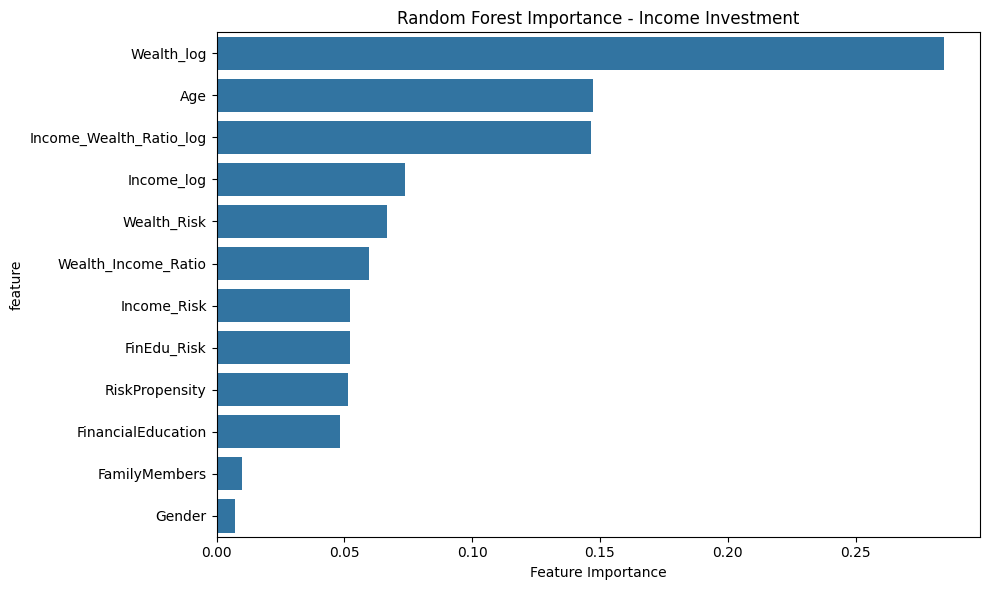

Generating SHAP Analysis for Random Forest...
SHAP failed for Random Forest: Model type not yet supported by TreeExplainer: <class 'sklearn.naive_bayes.GaussianNB'>
Generating LIME Analysis for Random Forest...


C:\Users\giova\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


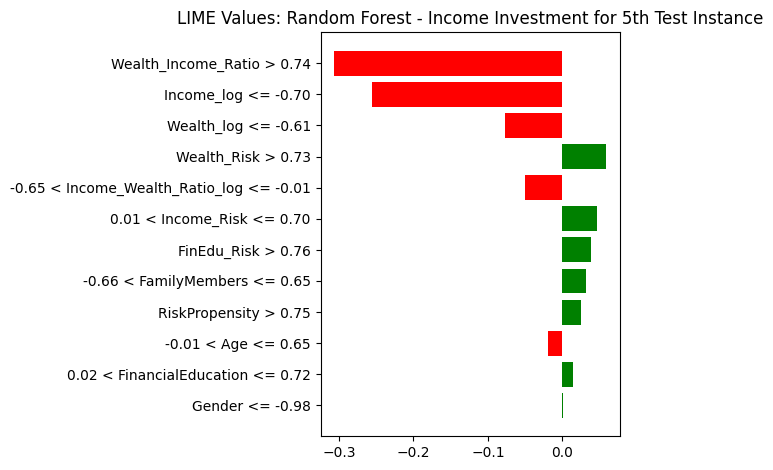


>>> Analyzing XGBoost for Income Investment
----------------------------------------
Generating Feature Importance for XGBoost...


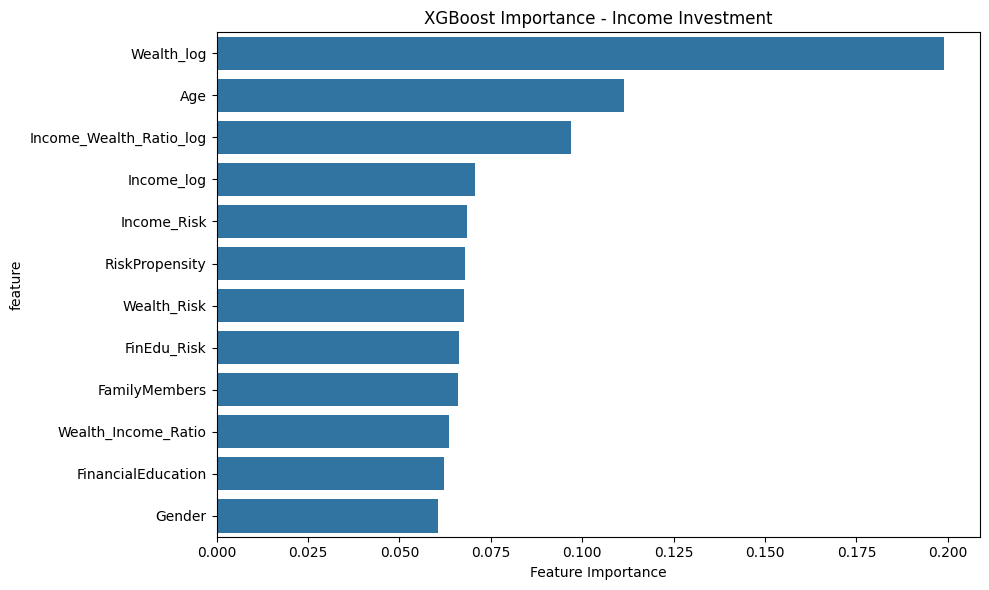

Generating SHAP Analysis for XGBoost...
SHAP failed for XGBoost: Model type not yet supported by TreeExplainer: <class 'sklearn.naive_bayes.GaussianNB'>
Generating LIME Analysis for XGBoost...


C:\Users\giova\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


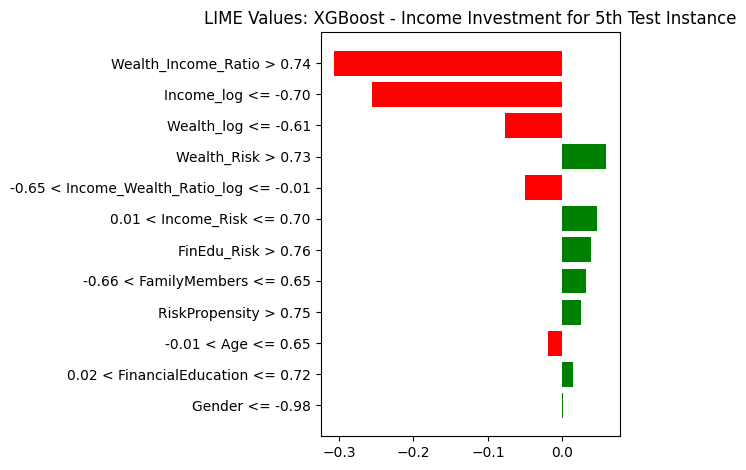


>>> Analyzing MLP (Neural Net) for Income Investment
----------------------------------------
Generating SHAP Analysis for MLP (Neural Net)...
SHAP failed for MLP (Neural Net): Model type not yet supported by TreeExplainer: <class 'sklearn.naive_bayes.GaussianNB'>
Generating LIME Analysis for MLP (Neural Net)...


C:\Users\giova\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


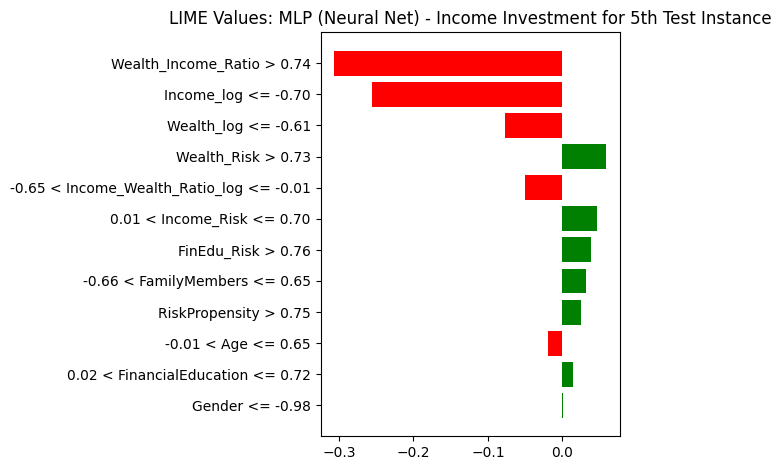



############################################################
 INTERPRETABILITY ANALYSIS: Accumulation Investment
############################################################

>>> Analyzing Random Forest for Accumulation Investment
----------------------------------------
Generating Feature Importance for Random Forest...


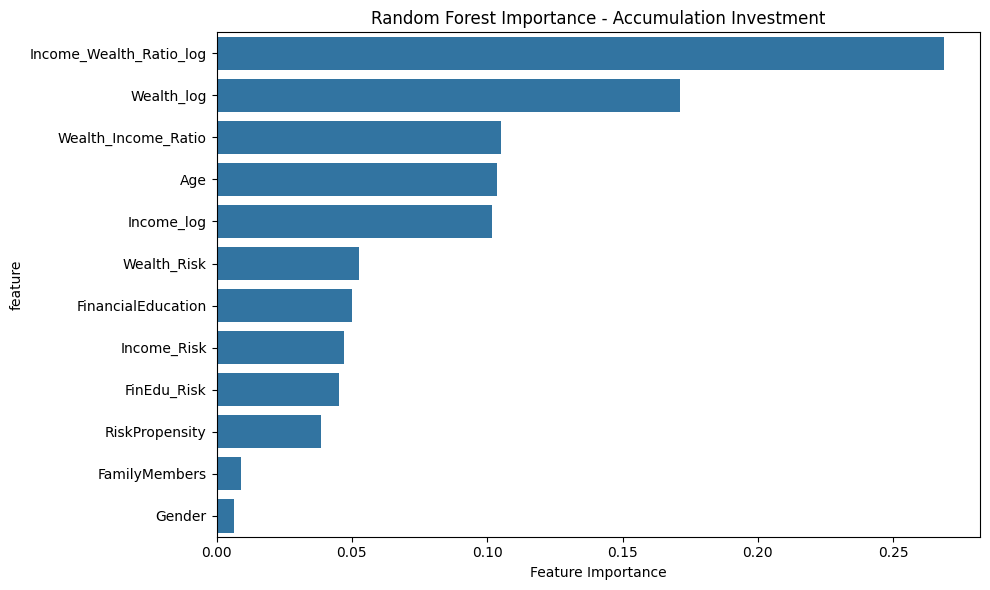

Generating SHAP Analysis for Random Forest...
SHAP failed for Random Forest: Model type not yet supported by TreeExplainer: <class 'sklearn.naive_bayes.GaussianNB'>
Generating LIME Analysis for Random Forest...


C:\Users\giova\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


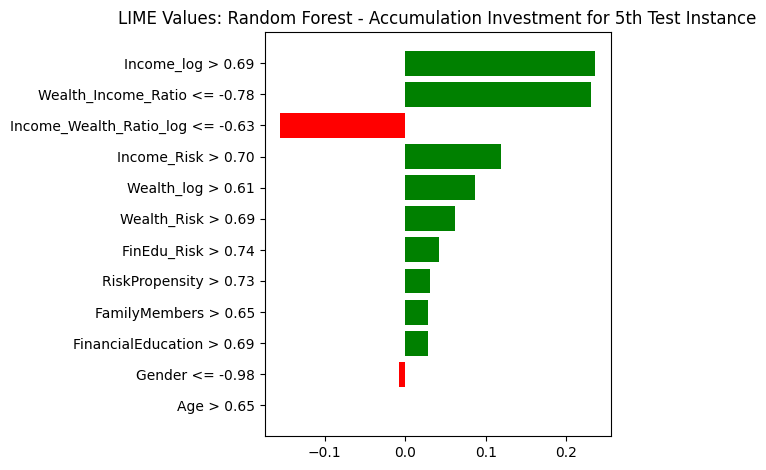


>>> Analyzing XGBoost for Accumulation Investment
----------------------------------------
Generating Feature Importance for XGBoost...


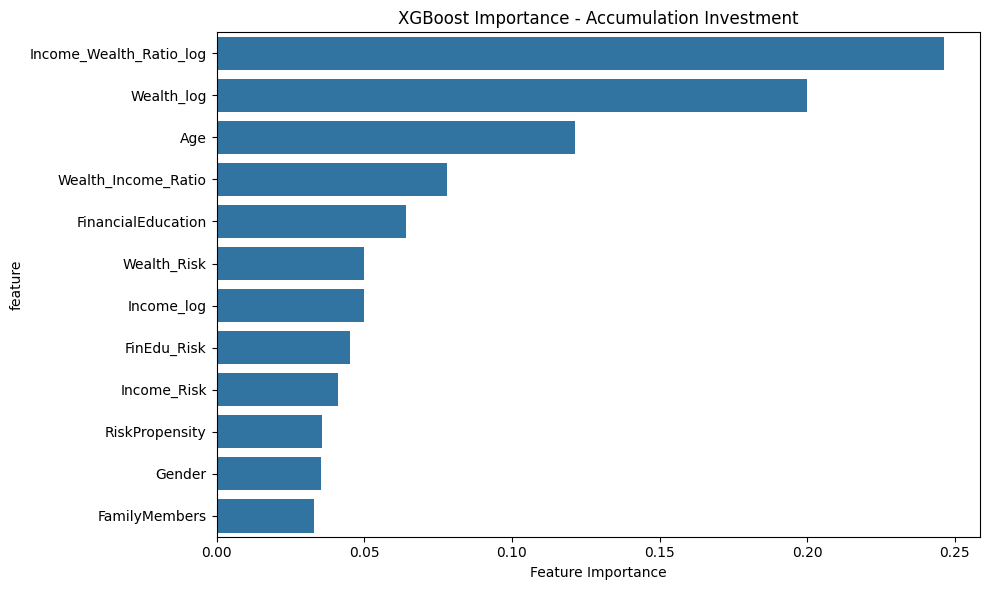

Generating SHAP Analysis for XGBoost...
SHAP failed for XGBoost: Model type not yet supported by TreeExplainer: <class 'sklearn.naive_bayes.GaussianNB'>
Generating LIME Analysis for XGBoost...


C:\Users\giova\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


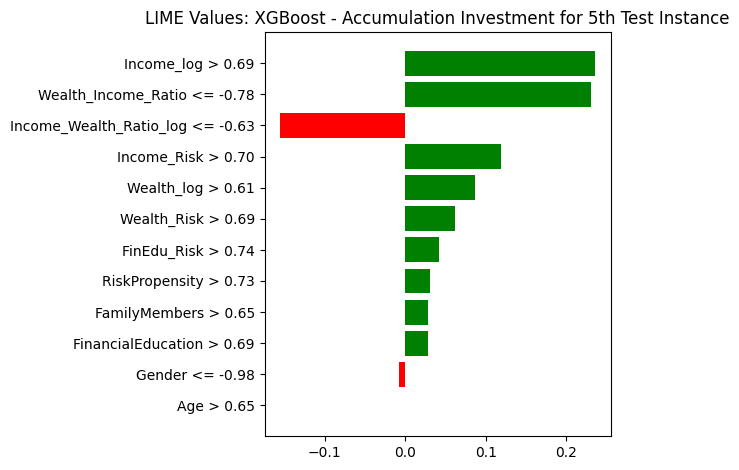


>>> Analyzing MLP (Neural Net) for Accumulation Investment
----------------------------------------
Generating SHAP Analysis for MLP (Neural Net)...
SHAP failed for MLP (Neural Net): Model type not yet supported by TreeExplainer: <class 'sklearn.naive_bayes.GaussianNB'>
Generating LIME Analysis for MLP (Neural Net)...


C:\Users\giova\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


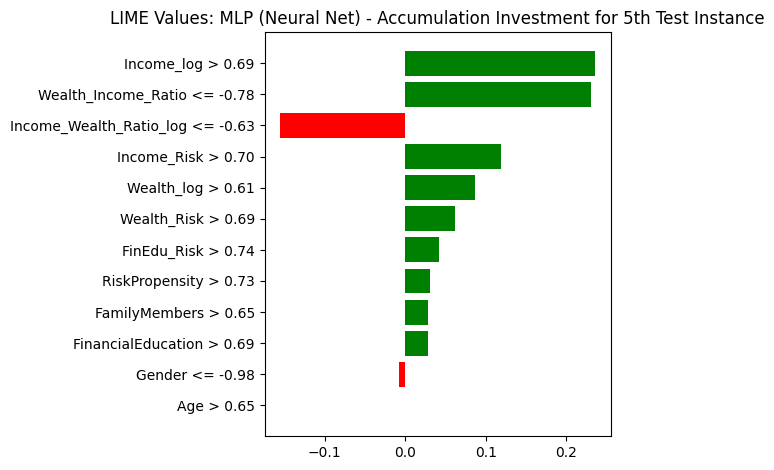

In [72]:
# Qui stampiamo i modelli migliori per ogni target e facciamo un'analisi di interpretabilità approfondita su ciascuno di essi, partendo dai modelli più performanti (Random Forest, XGBoost, MLP) 
# e applichiamo sia feature importance che SHAP e LIME per capire le decisioni del modello a livello globale e locale (ossia per una singola previsione, ho messo 5 come numero di esempi da analizzare localmente, ma si può aumentare o diminuire a seconda delle esigenze).

interpretability_targets = [
    ('Income Investment', y_income), 
    ('Accumulation Investment', y_accum)
]

for target_name, y in interpretability_targets:
    print(f"\n{'#'*60}")
    print(f" INTERPRETABILITY ANALYSIS: {target_name}")
    print(f"{'#'*60}")

    # Ensure we use the same split as the training phase
    X_eng_train, X_eng_test, y_train, y_test = split_data(X_engineered, y)
    
    # Define the models we want to interpret for this specific target
    current_models = {
        'Random Forest': best_rf_models[target_name],
        'XGBoost': best_xgb_models[target_name],
        'MLP (Neural Net)': best_mlp_models[target_name]
    }

    for model_name, model in current_models.items():
        print(f"\n>>> Analyzing {model_name} for {target_name}")
        print("-" * 40)

        # 1. Feature Importance (Only for Tree-based models)
        if hasattr(model, 'feature_importances_'):
            print(f"Generating Feature Importance for {model_name}...")
            plot_feature_importance(model, X_engineered.columns, f'{model_name} Importance - {target_name}')

        # 2. SHAP Analysis (Works for all, but uses different explainers)
        print(f"Generating SHAP Analysis for {model_name}...")
        try:
            plot_loc_shap_values(model, X_eng_test, f'SHAP Values: {model_name} - {target_name}', 5)
        except Exception as e:
            print(f"SHAP failed for {model_name}: {e}")

        # 3. LIME Analysis
        print(f"Generating LIME Analysis for {model_name}...")
        try:
            plot_loc_lime_values(model, X_eng_test, f'LIME Values: {model_name} - {target_name}', 5)
        except Exception as e:
            print(f"LIME failed for {model_name}: {e}")
            
    print("\n" + "="*60)

## Generate personalized recommendations
Predict client needs with the ensemble and prepare product recommendation inputs.

In [73]:
# Filter products by type
accumulation_products = products_df[products_df['Type'] == 1].copy()
income_products = products_df[products_df['Type'] == 0].copy()

# Min risk values (used later in matching logic)
min_risk_accum = accumulation_products['Risk'].min()
min_risk_income = income_products['Risk'].min()

print("\nGenerating predictions with the FULL ensemble (OOF + Stacking)")
print("=" * 80)

# Prepare features once
X_base, _ = prepare_features(needs_df)

def get_ensemble_predictions(target_name, X, use_stacking=True, return_proba=False):
    """
    Returns predictions from the ensemble.
    - use_stacking=True: use saved logistic meta-learner
    - use_stacking=False: use soft-voting average
    - return_proba=True: return probabilities instead of hard labels
    """
    if target_name not in best_rf_models or target_name not in best_xgb_models or target_name not in best_mlp_models:
        raise KeyError(f"Missing base model(s) for target: {target_name}")

    rf_proba  = best_rf_models[target_name].predict_proba(X)[:, 1]
    xgb_proba = best_xgb_models[target_name].predict_proba(X)[:, 1]
    mlp_proba = get_probas_from_mlp(best_mlp_models[target_name], X)

    if use_stacking:
        if 'meta_models' not in globals() or target_name not in meta_models:
            raise RuntimeError(
                f"Meta-learner for '{target_name}' not found. Run the ensemble loop cell first."
            )
        meta_features = np.column_stack([rf_proba, xgb_proba, mlp_proba])
        proba = meta_models[target_name].predict_proba(meta_features)[:, 1]
        if return_proba:
            return proba

        threshold = 0.5
        if 'ensemble_thresholds' in globals() and target_name in ensemble_thresholds:
            threshold = ensemble_thresholds[target_name].get('stacking', {}).get('threshold', 0.5)
        return (proba >= threshold).astype(int)

    soft_proba = (rf_proba + xgb_proba + mlp_proba) / 3
    if return_proba:
        return soft_proba

    threshold = 0.5
    if 'ensemble_thresholds' in globals() and target_name in ensemble_thresholds:
        threshold = ensemble_thresholds[target_name].get('soft_voting', {}).get('threshold', 0.5)
    return (soft_proba >= threshold).astype(int)

# Compute predictions for both needs with the saved ensemble pipeline
ensemble_results = {}
targets = [
    ('Income Investment', needs_df['IncomeInvestment']),
    ('Accumulation Investment', needs_df['AccumulationInvestment'])
]

for target_name, y_target in targets:
    X_train, X_test, y_train, y_test = split_data(X_engineered, y_target)
    y_pred = get_ensemble_predictions(target_name, X_test, use_stacking=True, return_proba=False)
    y_proba = get_ensemble_predictions(target_name, X_test, use_stacking=True, return_proba=True)

    ensemble_results[target_name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_proba': y_proba,
        'y_pred': y_pred,
        'meta_model': meta_models[target_name]
    }
    if 'ensemble_thresholds' in globals() and target_name in ensemble_thresholds:
        thr = ensemble_thresholds[target_name]['stacking']['threshold']
        print(f"{target_name}: threshold={thr:.4f}, predicted positives = {int(y_pred.sum())}/{len(y_pred)}")
    else:
        print(f"{target_name}: predicted positives = {int(y_pred.sum())}/{len(y_pred)}")

# Backward-compatible variables used by downstream recommendation cells
X_test = ensemble_results['Accumulation Investment']['X_test']
y_pred = ensemble_results['Accumulation Investment']['y_pred']

# Explicit outputs for both needs
y_pred_accum = ensemble_results['Accumulation Investment']['y_pred']
y_pred_income = ensemble_results['Income Investment']['y_pred']
y_proba_accum = ensemble_results['Accumulation Investment']['y_proba']
y_proba_income = ensemble_results['Income Investment']['y_proba']


Generating predictions with the FULL ensemble (OOF + Stacking)
Income Investment: threshold=0.3941, predicted positives = 271/1000
Accumulation Investment: threshold=0.3141, predicted positives = 537/1000


## Risk-based client-product matching
The next cell assigns at most one suitable product per client under strict risk constraints and summarizes diagnostics.


Recommendation rows generated:
Accumulation (all clients in split): 1000
Income (all clients in split): 1000
Total: 2000
Accumulation targeted positives: 537
Income targeted positives: 271

No-recommendation count (client risk below minimum product risk):
Accumulation unmatched count: 307
Income unmatched count: 42

Suitability violations (must be 0):
Accumulation violations: 0
Income violations: 0

Top 10 accumulation recommendations (all clients):
   ClientID  RecommendedProductID  ClientRiskPropensity  ProductRiskLevel  \
0      3879                     9              0.273216              0.27   
1       741                     9              0.336864              0.27   
2      3151                     0              0.263229               NaN   
3      4159                     9              0.326331              0.27   
4      4920                     0              0.166667               NaN   
5      2352                     1              0.567415              0.55   
6     

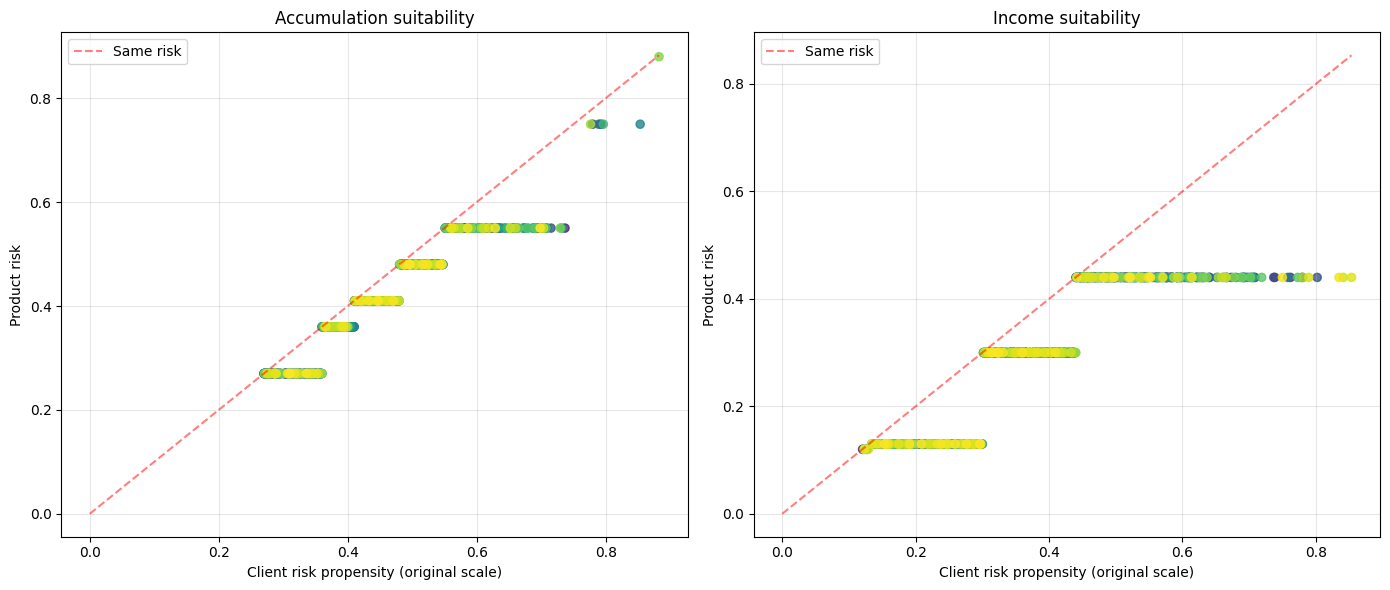

In [74]:
def build_recommendations_for_all_clients(X_clients, products_subset, need_type, reference_df):
    """
    Recommend at most one product per client using strict suitability.
    Rule: highest product risk <= client risk.
    If no feasible product exists, no recommendation is assigned (ID=0).
    """
    product_ids = products_subset['IDProduct'].astype(np.uint16).values
    product_risks = products_subset['Risk'].astype(float).values

    # Sort products once to make threshold search deterministic and efficient
    order = np.argsort(product_risks)
    product_ids_sorted = product_ids[order]
    product_risks_sorted = product_risks[order]

    client_ids = X_clients.index.values
    # IMPORTANT: use ORIGINAL risk scale (not MinMax-scaled X_base risk)
    client_risks = reference_df.loc[client_ids, 'RiskPropensity'].astype(float).values

    recommended_ids = []
    recommended_risks = []
    feasible_flags = []

    eps = 1e-12  # numerical tolerance
    for client_risk in client_risks:
        feasible_mask = product_risks_sorted <= (client_risk + eps)
        if feasible_mask.any():
            best_idx = np.where(feasible_mask)[0][-1]  # highest feasible risk
            recommended_ids.append(product_ids_sorted[best_idx])
            recommended_risks.append(product_risks_sorted[best_idx])
            feasible_flags.append(True)
        else:
            # Strict suitability: no recommendation if every product is too risky
            recommended_ids.append(0)
            recommended_risks.append(np.nan)
            feasible_flags.append(False)

    return pd.DataFrame({
        'ClientID': client_ids,
        'RecommendedProductID': recommended_ids,
        'ClientRiskPropensity': client_risks,
        'ProductRiskLevel': recommended_risks,
        'NeedType': need_type,
        'FeasibleWithoutFallback': feasible_flags
    })

# Build recommendation datasets from ensemble outputs
X_test_accum = ensemble_results['Accumulation Investment']['X_test']
X_test_income = ensemble_results['Income Investment']['X_test']

# 1) All-clients-by-need recommendation with strict risk suitability (original risk scale)
nba_accum_all_clients = build_recommendations_for_all_clients(
    X_test_accum, accumulation_products, 'Accumulation', needs_df
)
nba_income_all_clients = build_recommendations_for_all_clients(
    X_test_income, income_products, 'Income', needs_df
)

# 2) Predicted-positive subsets (aligned by client index to ensemble labels)
accum_pred_series = pd.Series(y_pred_accum, index=X_test_accum.index)
income_pred_series = pd.Series(y_pred_income, index=X_test_income.index)
nba_accum_targeted = nba_accum_all_clients.loc[accum_pred_series.loc[nba_accum_all_clients['ClientID']].values == 1].copy()
nba_income_targeted = nba_income_all_clients.loc[income_pred_series.loc[nba_income_all_clients['ClientID']].values == 1].copy()

# Keep old variable names backward-compatible
nba_accum = nba_accum_all_clients.copy()
nba_income = nba_income_all_clients.copy()
nba_all = pd.concat([nba_accum, nba_income], ignore_index=True)
nba = nba_accum.copy()

print("\nRecommendation rows generated:")
print(f"Accumulation (all clients in split): {len(nba_accum_all_clients)}")
print(f"Income (all clients in split): {len(nba_income_all_clients)}")
print(f"Total: {len(nba_all)}")
print(f"Accumulation targeted positives: {len(nba_accum_targeted)}")
print(f"Income targeted positives: {len(nba_income_targeted)}")

# Unmatched diagnostics under strict suitability
acc_unmatched = (~nba_accum_all_clients['FeasibleWithoutFallback']).sum()
inc_unmatched = (~nba_income_all_clients['FeasibleWithoutFallback']).sum()
print(f"\nNo-recommendation count (client risk below minimum product risk):")
print(f"Accumulation unmatched count: {acc_unmatched}")
print(f"Income unmatched count: {inc_unmatched}")

# Hard suitability checks on recommended rows
acc_violations = (
    nba_accum_all_clients.loc[nba_accum_all_clients['RecommendedProductID'] > 0, 'ProductRiskLevel']
    > nba_accum_all_clients.loc[nba_accum_all_clients['RecommendedProductID'] > 0, 'ClientRiskPropensity'] + 1e-12
).sum()
inc_violations = (
    nba_income_all_clients.loc[nba_income_all_clients['RecommendedProductID'] > 0, 'ProductRiskLevel']
    > nba_income_all_clients.loc[nba_income_all_clients['RecommendedProductID'] > 0, 'ClientRiskPropensity'] + 1e-12
).sum()
print(f"\nSuitability violations (must be 0):")
print(f"Accumulation violations: {int(acc_violations)}")
print(f"Income violations: {int(inc_violations)}")

print("\nTop 10 accumulation recommendations (all clients):")
print(nba_accum_all_clients.head(10))

print("\nTop 10 income recommendations (all clients):")
print(nba_income_all_clients.head(10))

# Suitability check plots for both need types (only recommended points)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df_plot, title in [
    (axes[0], nba_accum_all_clients, 'Accumulation suitability'),
    (axes[1], nba_income_all_clients, 'Income suitability')
  ]:
    df_rec = df_plot[df_plot['RecommendedProductID'] > 0].copy()
    if len(df_rec) > 0:
        ax.scatter(
            df_rec['ClientRiskPropensity'],
            df_rec['ProductRiskLevel'],
            c=range(len(df_rec)),
            cmap='viridis',
            alpha=0.8,
            s=35
        )
    y_max = df_rec['ProductRiskLevel'].max() if len(df_rec) > 0 else 0.0
    max_val = max(df_plot['ClientRiskPropensity'].max(), y_max)
    ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Same risk')
    ax.set_title(title)
    ax.set_xlabel('Client risk propensity (original scale)')
    ax.set_ylabel('Product risk')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## Analyze recommendation outcomes
Coverage, product-frequency distributions, and summary statistics of generated recommendations.


Recommendation statistics - Accumulation (all clients)
Total clients analyzed: 1000
Clients with recommendations: 693 (69.30%)
Clients without feasible product: 307


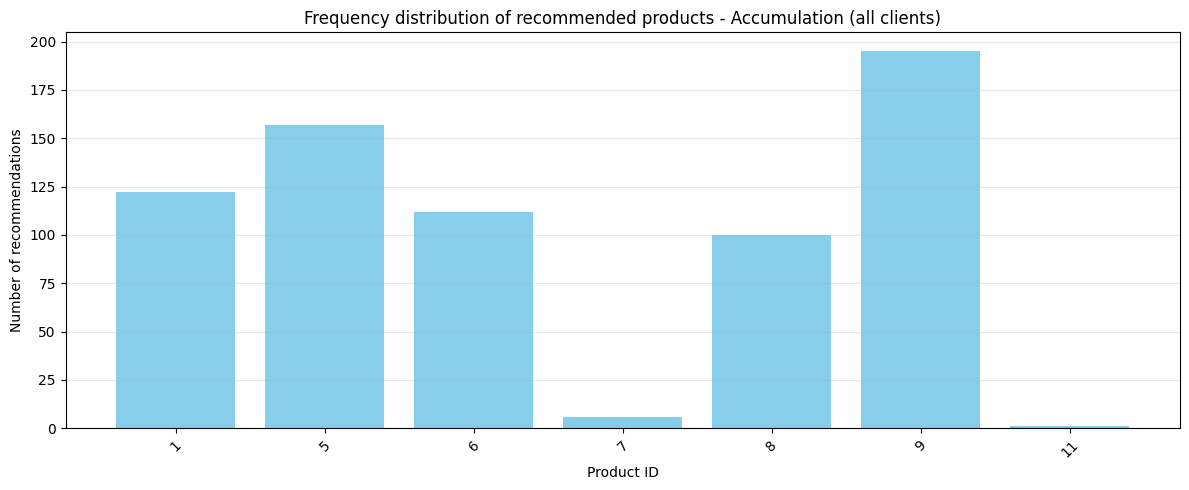


Details on the most recommended products:

Product ID: 9
Risk: 0.27
Recommended to 195 clients

Product ID: 5
Risk: 0.41
Recommended to 157 clients

Product ID: 1
Risk: 0.55
Recommended to 122 clients

Recommendation statistics - Income (all clients)
Total clients analyzed: 1000
Clients with recommendations: 958 (95.80%)
Clients without feasible product: 42


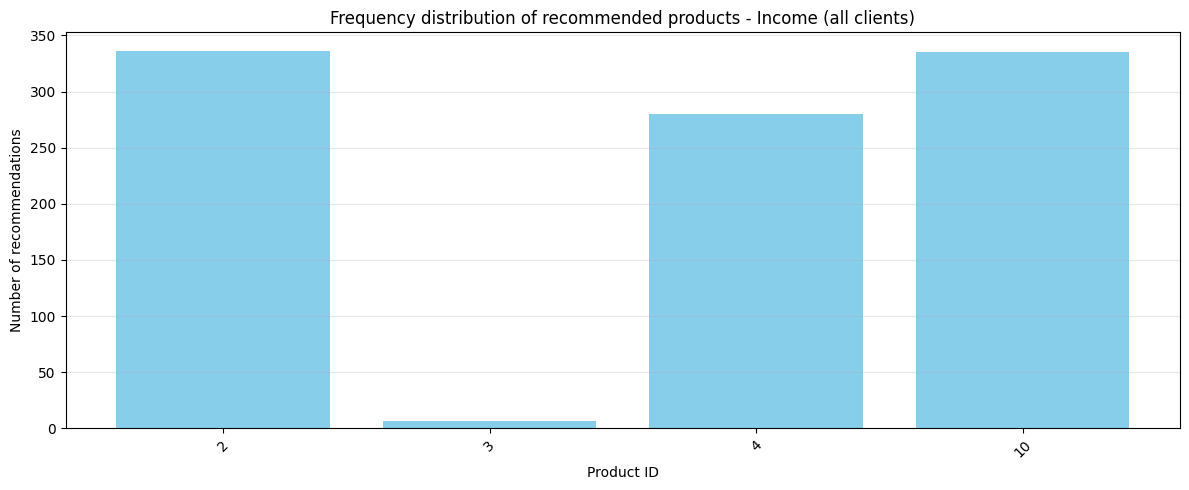


Details on the most recommended products:

Product ID: 2
Risk: 0.3
Recommended to 336 clients

Product ID: 10
Risk: 0.13
Recommended to 335 clients

Product ID: 4
Risk: 0.44
Recommended to 280 clients

Overall recommendation summary
Accumulation targeted rows: 537
Income targeted rows: 271
Total recommendations: 808


In [75]:
def analyze_recommendations(nba_df, products_subset, need_label):
    print(f"\n{'=' * 80}")
    print(f"Recommendation statistics - {need_label}")
    print(f"{'=' * 80}")

    total_clients = len(nba_df)
    clients_with_recommendations = len(nba_df[nba_df['RecommendedProductID'] > 0])
    pct_with_recommendations = (clients_with_recommendations / total_clients * 100) if total_clients > 0 else 0.0

    unmatched_count = 0
    if 'FeasibleWithoutFallback' in nba_df.columns:
        unmatched_count = (~nba_df['FeasibleWithoutFallback']).sum()

    print(f"Total clients analyzed: {total_clients}")
    print(
        f"Clients with recommendations: {clients_with_recommendations} "
        f"({pct_with_recommendations:.2f}%)"
    )
    print(f"Clients without feasible product: {unmatched_count}")

    if clients_with_recommendations == 0:
        print("No products were recommended in this segment.")
        return

    recommendation_counts = nba_df['RecommendedProductID'].value_counts().sort_index()
    recommendation_counts = recommendation_counts[recommendation_counts.index > 0]

    plt.figure(figsize=(12, 5))
    plt.bar(recommendation_counts.index.astype(str), recommendation_counts.values, color='skyblue')
    plt.title(f'Frequency distribution of recommended products - {need_label}')
    plt.xlabel('Product ID')
    plt.ylabel('Number of recommendations')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    top_products = recommendation_counts.nlargest(3).index
    print("\nDetails on the most recommended products:")
    for prod_id in top_products:
        product_details = products_subset[products_subset['IDProduct'] == prod_id]
        print(f"\nProduct ID: {prod_id}")
        print(f"Risk: {product_details['Risk'].values[0]}")
        print(f"Recommended to {recommendation_counts[prod_id]} clients")

# Analyze all-client recommendation streams
analyze_recommendations(nba_accum_all_clients, accumulation_products, 'Accumulation (all clients)')
analyze_recommendations(nba_income_all_clients, income_products, 'Income (all clients)')

# Combined high-level summary
print(f"\n{'=' * 80}")
print("Overall recommendation summary")
print(f"{'=' * 80}")
print(f"Accumulation targeted rows: {len(nba_accum_targeted)}")
print(f"Income targeted rows: {len(nba_income_targeted)}")
print(f"Total recommendations: {len(nba_accum_targeted) + len(nba_income_targeted)}")